# GPS Data Quality & Exploratory Data Analysis

## Objective

This notebook analyzes raw GPS trajectory data to understand:

- GPS coordinate quality
- Timestamp consistency
- Sampling intervals
- Missing and duplicate records
- GPS jumps
- Unrealistic movement speeds
- Trajectory patterns
- Geographic coverage
- Data-quality anomalies

The objective is to prepare a reliable GPS dataset for the
Guard Patrol Anomaly Detection system.

> Note:
> The public GPS dataset is used for GPS pipeline development
> and validation. It is not treated as real VIGILOX guard data.

## Dataset Information

The dataset contains GPS trajectories collected from multiple
users over time.

For this project, the trajectory data is used to develop and
validate the GPS data ingestion, cleaning, quality validation,
and feature engineering pipeline.

The dataset is not assumed to represent actual guard patrol
behavior.

# Import Libraries 

In [38]:
import zipfile
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Project Paths

In [39]:
from pathlib import Path

# Project root
PROJECT_DIR = Path.cwd().parent

# Data directories
RAW_DATA_DIR = PROJECT_DIR / "data" / "raw"
INTERIM_DATA_DIR = PROJECT_DIR / "data" / "interim"
PROCESSED_DATA_DIR = PROJECT_DIR / "data" / "processed"

# Geolife directories
GEOLIFE_DIR = RAW_DATA_DIR / "Geolife Trajectories 1.3"
GEOLIFE_DATA_DIR = GEOLIFE_DIR / "Data"

# Output directory for processed Geolife batches
GEOLIFE_OUTPUT_DIR = INTERIM_DATA_DIR / "geolife"

# Create output directory if it doesn't exist
GEOLIFE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Project:", PROJECT_DIR)
print("Geolife:", GEOLIFE_DATA_DIR)
print("Output:", GEOLIFE_OUTPUT_DIR)

Project: e:\Internship\Guard_Patrol_Anomaly_Detection
Geolife: e:\Internship\Guard_Patrol_Anomaly_Detection\data\raw\Geolife Trajectories 1.3\Data
Output: e:\Internship\Guard_Patrol_Anomaly_Detection\data\interim\geolife


## Check Folder Name 

In [40]:
print("Project:", PROJECT_DIR)
print("\nFolders inside data/raw:")

for item in RAW_DATA_DIR.iterdir():
    print(item.name)

Project: e:\Internship\Guard_Patrol_Anomaly_Detection

Folders inside data/raw:
checkins
external
geolife
Geolife Trajectories 1.3
Geolife Trajectories 1.3.zip
gps
incidents
osm
patrols


# Locate GeoLife Folder

In [41]:
GEOLIFE_DIR = RAW_DATA_DIR / "Geolife Trajectories 1.3"

print("GeoLife directory:")
print(GEOLIFE_DIR)

print("\nContents:")

for item in GEOLIFE_DIR.iterdir():
    print(item.name)

GeoLife directory:
e:\Internship\Guard_Patrol_Anomaly_Detection\data\raw\Geolife Trajectories 1.3

Contents:
Data
User Guide-1.3.pdf


# Check User of data 

In [42]:
GEOLIFE_DATA_DIR = GEOLIFE_DIR / "Data"

print("GeoLife Data directory:")
print(GEOLIFE_DATA_DIR)

print("\nUsers:")

for item in GEOLIFE_DATA_DIR.iterdir():
    if item.is_dir():
        print(item.name)

GeoLife Data directory:
e:\Internship\Guard_Patrol_Anomaly_Detection\data\raw\Geolife Trajectories 1.3\Data

Users:
000
001
002
003
004
005
006
007
008
009
010
011
012
013
014
015
016
017
018
019
020
021
022
023
024
025
026
027
028
029
030
031
032
033
034
035
036
037
038
039
040
041
042
043
044
045
046
047
048
049
050
051
052
053
054
055
056
057
058
059
060
061
062
063
064
065
066
067
068
069
070
071
072
073
074
075
076
077
078
079
080
081
082
083
084
085
086
087
088
089
090
091
092
093
094
095
096
097
098
099
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181


# Verify Trajectory Folder 

In [43]:
trajectory_dirs = list(
    GEOLIFE_DATA_DIR.glob("*/Trajectory")
)

print(f"Trajectory folders found: {len(trajectory_dirs)}")

for folder in trajectory_dirs[:5]:
    print(folder)

Trajectory folders found: 182
e:\Internship\Guard_Patrol_Anomaly_Detection\data\raw\Geolife Trajectories 1.3\Data\000\Trajectory
e:\Internship\Guard_Patrol_Anomaly_Detection\data\raw\Geolife Trajectories 1.3\Data\001\Trajectory
e:\Internship\Guard_Patrol_Anomaly_Detection\data\raw\Geolife Trajectories 1.3\Data\002\Trajectory
e:\Internship\Guard_Patrol_Anomaly_Detection\data\raw\Geolife Trajectories 1.3\Data\003\Trajectory
e:\Internship\Guard_Patrol_Anomaly_Detection\data\raw\Geolife Trajectories 1.3\Data\004\Trajectory


# Find .plt Files

In [44]:
trajectory_files = list(
    GEOLIFE_DATA_DIR.glob("*/Trajectory/*.plt")
)

print(f"Total trajectory files found: {len(trajectory_files)}")


Total trajectory files found: 18670


In [45]:
GEOLIFE_DIR = RAW_DATA_DIR / "Geolife Trajectories 1.3"

for item in GEOLIFE_DIR.iterdir():
    print(item.name)

Data
User Guide-1.3.pdf


In [46]:
GEOLIFE_DATA_DIR = GEOLIFE_DIR / "Data"

for item in GEOLIFE_DATA_DIR.iterdir():
    if item.is_dir():
        print(item.name)

000
001
002
003
004
005
006
007
008
009
010
011
012
013
014
015
016
017
018
019
020
021
022
023
024
025
026
027
028
029
030
031
032
033
034
035
036
037
038
039
040
041
042
043
044
045
046
047
048
049
050
051
052
053
054
055
056
057
058
059
060
061
062
063
064
065
066
067
068
069
070
071
072
073
074
075
076
077
078
079
080
081
082
083
084
085
086
087
088
089
090
091
092
093
094
095
096
097
098
099
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181


In [47]:
trajectory_files = list(
    GEOLIFE_DATA_DIR.glob("*/Trajectory/*.plt")
)

print(f"Number of trajectory files: {len(trajectory_files)}")

Number of trajectory files: 18670


#  Select .plt File 

In [48]:
sample_file = trajectory_files[0]
print("Sample trajectory file:")
print(sample_file)

Sample trajectory file:
e:\Internship\Guard_Patrol_Anomaly_Detection\data\raw\Geolife Trajectories 1.3\Data\000\Trajectory\20081023025304.plt


# Show First 15 Lines 

In [49]:
with open(sample_file, "r", encoding="utf-8") as file:
    for i in range(15):
        print(file.readline().rstrip())

Geolife trajectory
WGS 84
Altitude is in Feet
Reserved 3
0,2,255,My Track,0,0,2,8421376
0
39.984702,116.318417,0,492,39744.1201851852,2008-10-23,02:53:04
39.984683,116.31845,0,492,39744.1202546296,2008-10-23,02:53:10
39.984686,116.318417,0,492,39744.1203125,2008-10-23,02:53:15
39.984688,116.318385,0,492,39744.1203703704,2008-10-23,02:53:20
39.984655,116.318263,0,492,39744.1204282407,2008-10-23,02:53:25
39.984611,116.318026,0,493,39744.1204861111,2008-10-23,02:53:30
39.984608,116.317761,0,493,39744.1205439815,2008-10-23,02:53:35
39.984563,116.317517,0,496,39744.1206018519,2008-10-23,02:53:40
39.984539,116.317294,0,500,39744.1206597222,2008-10-23,02:53:45


# Check File Size

In [50]:
print(f"File size: {sample_file.stat().st_size / 1024:.2f} KB")

File size: 57.29 KB


# How much GPS records each Trajectory File Contain

In [51]:
with open(sample_file, "r", encoding="utf-8") as file:
    line_count = sum(1 for _ in file)

print(f"Total lines: {line_count}")

Total lines: 914


**we will nt load 18,670 files at a time using pandas**
We will  load 1 file 

Understand the format 

Build parser

Test Parser

Then Scale to all files


## GPS Data Dictionary

# | Field   | Description | Project Role |

| latitude  | GPS latitude | Location |

| longitude | GPS longitude | Location |

| altitude  | Recorded altitude | Movement context |

| timestamp | Date + time of GPS event | Temporal analysis |

| entity_id | GeoLife user identifier | Temporary guard proxy |

In [52]:
sample_file = trajectory_files[0]

print("Sample trajectory file:")
print(sample_file)

Sample trajectory file:
e:\Internship\Guard_Patrol_Anomaly_Detection\data\raw\Geolife Trajectories 1.3\Data\000\Trajectory\20081023025304.plt


In [53]:
with open(sample_file, "r", encoding="utf-8") as file:
    for i in range(15):
        print(file.readline().rstrip())

Geolife trajectory
WGS 84
Altitude is in Feet
Reserved 3
0,2,255,My Track,0,0,2,8421376
0
39.984702,116.318417,0,492,39744.1201851852,2008-10-23,02:53:04
39.984683,116.31845,0,492,39744.1202546296,2008-10-23,02:53:10
39.984686,116.318417,0,492,39744.1203125,2008-10-23,02:53:15
39.984688,116.318385,0,492,39744.1203703704,2008-10-23,02:53:20
39.984655,116.318263,0,492,39744.1204282407,2008-10-23,02:53:25
39.984611,116.318026,0,493,39744.1204861111,2008-10-23,02:53:30
39.984608,116.317761,0,493,39744.1205439815,2008-10-23,02:53:35
39.984563,116.317517,0,496,39744.1206018519,2008-10-23,02:53:40
39.984539,116.317294,0,500,39744.1206597222,2008-10-23,02:53:45


In [54]:
print(f"File size: {sample_file.stat().st_size / 1024:.2f} KB")

with open(sample_file, "r", encoding="utf-8") as file:
    line_count = sum(1 for _ in file)

print(f"Total lines: {line_count}")

File size: 57.29 KB
Total lines: 914


## Create Parser

In [55]:
import pandas as pd
raw_columns = [
    "latitude",
    "longitude",
    "reserved",
    "altitude_ft",
    "date_serial",
    "date",
    "time",
]
sample_df = pd.read_csv(
    sample_file,
    skiprows=6,
    header=None,
    names=raw_columns
)

sample_df.head()

,latitude,longitude,reserved,altitude_ft,date_serial,date,time
0,39.984702,116.318417,0,492,39744.120185,2008-10-23,02:53:04
1,39.984683,116.318450,0,492,39744.120255,2008-10-23,02:53:10
2,39.984686,116.318417,0,492,39744.120313,2008-10-23,02:53:15
3,39.984688,116.318385,0,492,39744.120370,2008-10-23,02:53:20
4,39.984655,116.318263,0,492,39744.120428,2008-10-23,02:53:25


# Check Structure of DataFrame  

In [56]:
print(sample_df.shape)
print(sample_df.columns.tolist())

(908, 7)
['latitude', 'longitude', 'reserved', 'altitude_ft', 'date_serial', 'date', 'time']


 914 actual lines, 
 6  meta data lines,  
 908 gps records 

# Check DataType 

In [57]:
sample_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   latitude     908 non-null    float64
 1   longitude    908 non-null    float64
 2   reserved     908 non-null    int64  
 3   altitude_ft  908 non-null    int64  
 4   date_serial  908 non-null    float64
 5   date         908 non-null    object 
 6   time         908 non-null    object 
dtypes: float64(3), int64(2), object(2)
memory usage: 49.8+ KB


## Create TimeStamp

In [58]:
sample_df["timestamp"] = pd.to_datetime(
    sample_df["date"] + " " + sample_df["time"],
    errors="coerce"
)

In [59]:
sample_df[
    ["date", "time", "timestamp"]
].head()

,date,time,timestamp
0,2008-10-23,02:53:04,2008-10-23 02:53:04
1,2008-10-23,02:53:10,2008-10-23 02:53:10
2,2008-10-23,02:53:15,2008-10-23 02:53:15
3,2008-10-23,02:53:20,2008-10-23 02:53:20
4,2008-10-23,02:53:25,2008-10-23 02:53:25


## Create Entity_id 

In [60]:
sample_df["entity_id"] = sample_file.parent.parent.name

In [61]:
# Check
sample_df["entity_id"].unique()

array(['000'], dtype=object)

## Convert Raw data in to Gps Schema 

In [62]:
gps_df = sample_df[
    [
        "entity_id",
        "timestamp",
        "latitude",
        "longitude",
        "altitude_ft",
    ]
].copy()

In [63]:
gps_df.head()

,entity_id,timestamp,latitude,longitude,altitude_ft
0,000,2008-10-23 02:53:04,39.984702,116.318417,492
1,000,2008-10-23 02:53:10,39.984683,116.318450,492
2,000,2008-10-23 02:53:15,39.984686,116.318417,492
3,000,2008-10-23 02:53:20,39.984688,116.318385,492
4,000,2008-10-23 02:53:25,39.984655,116.318263,492


# we have created a standard data frame / Parse 

## Exploratory Data Analysis 

# Check  Null Values 

In [64]:
gps_df.isna().sum()

entity_id      0
timestamp      0
latitude       0
longitude      0
altitude_ft    0
dtype: int64

In [65]:
gps_df.duplicated().sum()

np.int64(0)

In [66]:
gps_df.describe()

,timestamp,latitude,longitude,altitude_ft
count,908,908.000000,908.000000,908.000000
mean,2008-10-23 06:57:06.887665152,39.998040,116.315561,398.093612
min,2008-10-23 02:53:04,39.983276,116.285446,-407.000000
25%,2008-10-23 04:14:55.750000128,39.985143,116.310045,130.000000
50%,2008-10-23 04:33:39.500000,39.999658,116.319314,153.000000
75%,2008-10-23 10:08:57.249999872,40.008201,116.321480,206.000000
max,2008-10-23 11:11:12,40.009428,116.324886,7584.000000
std,NaN,0.010490,0.007881,1190.964197


# Cordinate Validation 

In [67]:
invalid_coordinates = gps_df[
    (~gps_df["latitude"].between(-90, 90))
    |
    (~gps_df["longitude"].between(-180, 180))
]

print(f"Invalid coordinate records: {len(invalid_coordinates)}")

Invalid coordinate records: 0


## After validating This parser we will converter this parser into reusable functions 

## 4. Reusable GeoLife Parser

The GeoLife dataset contains individual trajectory files in `.plt` format.

We first validated the structure using one sample file.  
Now we create a reusable parser that converts any GeoLife trajectory file into our standardized GPS schema.

In [68]:
import pandas as pd
from pathlib import Path


def parse_geolife_file(file_path: Path) -> pd.DataFrame:
    """Parse one GeoLife .plt trajectory file."""
    
    columns = [
        "latitude",
        "longitude",
        "reserved",
        "altitude_ft",
        "date_serial",
        "date",
        "time",
    ]

    df = pd.read_csv(
        file_path,
        skiprows=6,
        header=None,
        names=columns,
    )

    # Create timestamp
    df["timestamp"] = pd.to_datetime(
        df["date"] + " " + df["time"],
        errors="coerce",
    )

    # Extract GeoLife user/entity ID
    df["entity_id"] = file_path.parent.parent.name

    # Keep standardized project fields
    df = df[
        [
            "entity_id",
            "timestamp",
            "latitude",
            "longitude",
            "altitude_ft",
        ]
    ].copy()

    return df

# Test Parser on Sample File 

In [69]:
test_df = parse_geolife_file(sample_file)

print(test_df.head())
print()
print("Shape:", test_df.shape)
print()
print(test_df.info())

  entity_id           timestamp   latitude   longitude  altitude_ft
0       000 2008-10-23 02:53:04  39.984702  116.318417          492
1       000 2008-10-23 02:53:10  39.984683  116.318450          492
2       000 2008-10-23 02:53:15  39.984686  116.318417          492
3       000 2008-10-23 02:53:20  39.984688  116.318385          492
4       000 2008-10-23 02:53:25  39.984655  116.318263          492

Shape: (908, 5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   entity_id    908 non-null    object        
 1   timestamp    908 non-null    datetime64[ns]
 2   latitude     908 non-null    float64       
 3   longitude    908 non-null    float64       
 4   altitude_ft  908 non-null    int64         
dtypes: datetime64[ns](1), float64(2), int64(1), object(1)
memory usage: 35.6+ KB
None


# Parse Validation 

Automatically check either parse create garbage data or not

In [70]:
print("Missing values:")
print(test_df.isna().sum())

print("\nDuplicate rows:")
print(test_df.duplicated().sum())

print("\nInvalid latitude:")
print(
    (~test_df["latitude"].between(-90, 90)).sum()
)

print("\nInvalid longitude:")
print(
    (~test_df["longitude"].between(-180, 180)).sum()
)

Missing values:
entity_id      0
timestamp      0
latitude       0
longitude      0
altitude_ft    0
dtype: int64

Duplicate rows:
0

Invalid latitude:
0

Invalid longitude:
0


# Time Stamp Validation 

In [71]:
print("Invalid timestamps:")
print(test_df["timestamp"].isna().sum())

Invalid timestamps:
0


In [72]:
print("Time range:")
print(test_df["timestamp"].min())
print(test_df["timestamp"].max())

Time range:
2008-10-23 02:53:04
2008-10-23 11:11:12


In [73]:
print("Timestamp sorted:", test_df["timestamp"].is_monotonic_increasing)

Timestamp sorted: True


# TimeStamps Gaps 

In [74]:
test_df = test_df.sort_values("timestamp").copy()

test_df["time_diff_seconds"] = (
    test_df["timestamp"]
    .diff()
    .dt.total_seconds()
)

test_df["time_diff_seconds"].describe()

count      907.000000
mean        32.952591
std        627.101101
min          1.000000
25%          5.000000
50%          5.000000
75%          5.000000
max      18453.000000
Name: time_diff_seconds, dtype: float64

# Test Parser on Multiple Files 

In [75]:
sample_files = trajectory_files[:5]

for file_path in sample_files:
    df = parse_geolife_file(file_path)

    print(
        file_path.name,
        "→",
        df.shape,
        "records"
    )

20081023025304.plt → (908, 5) records
20081024020959.plt → (244, 5) records
20081026134407.plt → (745, 5) records
20081027115449.plt → (50, 5) records
20081028003826.plt → (1477, 5) records


# Combine 5 Files 

In [76]:
test_dfs = [
    parse_geolife_file(file_path)
    for file_path in trajectory_files[:5]
]

test_combined_df = pd.concat(
    test_dfs,
    ignore_index=True
)

print("Combined shape:", test_combined_df.shape)
print(test_combined_df.head())

Combined shape: (3424, 5)
  entity_id           timestamp   latitude   longitude  altitude_ft
0       000 2008-10-23 02:53:04  39.984702  116.318417          492
1       000 2008-10-23 02:53:10  39.984683  116.318450          492
2       000 2008-10-23 02:53:15  39.984686  116.318417          492
3       000 2008-10-23 02:53:20  39.984688  116.318385          492
4       000 2008-10-23 02:53:25  39.984655  116.318263          492


# Verify Entity ids

In [77]:
print(
    test_combined_df["entity_id"].unique()
)

['000']


In [78]:
print(
    test_combined_df["entity_id"].value_counts()
)

entity_id
000    3424
Name: count, dtype: int64


In [79]:
test_df.shape

(908, 6)

In [80]:
test_df["time_diff_seconds"].describe()

count      907.000000
mean        32.952591
std        627.101101
min          1.000000
25%          5.000000
50%          5.000000
75%          5.000000
max      18453.000000
Name: time_diff_seconds, dtype: float64

In [81]:
test_combined_df.shape

(3424, 5)

# Batch Parser

18,670 files
      ↓
Reusable parser
      ↓
Validation
      ↓
Batch processing
      ↓
Interim dataset

## 5. Batch Processing of GeoLife GPS Data

The GeoLife dataset contains 18,670 trajectory files.

Instead of manually processing individual files, we now apply the validated parser to the complete dataset.

The batch pipeline will:
- Parse each trajectory file
- Preserve the entity ID
- Validate GPS coordinates
- Validate timestamps
- Track processing errors
- Combine valid records
- Save the result as an intermediate dataset

In [82]:
from pathlib import Path
import pandas as pd
import time

# Create a Processing Function

In [83]:
def process_geolife_file(file_path: Path):
    """
    Parse and validate a single GeoLife trajectory file.
    
    Returns:
        DataFrame: Valid parsed GPS records
        None: If processing fails
    """
    
    try:
        df = parse_geolife_file(file_path)

        # Remove rows with invalid timestamps
        df = df.dropna(
            subset=["timestamp"]
        )

        # Keep only valid geographic coordinates
        df = df[
            df["latitude"].between(-90, 90)
            & df["longitude"].between(-180, 180)
        ]

        # Sort chronologically
        df = df.sort_values("timestamp")

        return df

    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

# Test on 100 files 

In [84]:
test_files = trajectory_files[:100]

processed_dfs = []
failed_files = []

start_time = time.time()

for file_path in test_files:

    df = process_geolife_file(file_path)

    if df is not None and not df.empty:
        processed_dfs.append(df)
    else:
        failed_files.append(file_path)

elapsed_time = time.time() - start_time

print(f"Files processed: {len(test_files)}")
print(f"Successful files: {len(processed_dfs)}")
print(f"Failed files: {len(failed_files)}")
print(f"Time taken: {elapsed_time:.2f} seconds")

Files processed: 100
Successful files: 100
Failed files: 0
Time taken: 5.58 seconds


# Combine 100 Files

In [85]:
test_100_df = pd.concat(
    processed_dfs,
    ignore_index=True
)

print("Combined dataset shape:")
print(test_100_df.shape)

Combined dataset shape:
(89252, 5)


In [86]:
test_100_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89252 entries, 0 to 89251
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   entity_id    89252 non-null  object        
 1   timestamp    89252 non-null  datetime64[ns]
 2   latitude     89252 non-null  float64       
 3   longitude    89252 non-null  float64       
 4   altitude_ft  89252 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(1), object(1)
memory usage: 3.4+ MB


In [87]:
test_100_df.head()

,entity_id,timestamp,latitude,longitude,altitude_ft
0,000,2008-10-23 02:53:04,39.984702,116.318417,492
1,000,2008-10-23 02:53:10,39.984683,116.318450,492
2,000,2008-10-23 02:53:15,39.984686,116.318417,492
3,000,2008-10-23 02:53:20,39.984688,116.318385,492
4,000,2008-10-23 02:53:25,39.984655,116.318263,492


In [88]:
test_100_df.head()

,entity_id,timestamp,latitude,longitude,altitude_ft
0,000,2008-10-23 02:53:04,39.984702,116.318417,492
1,000,2008-10-23 02:53:10,39.984683,116.318450,492
2,000,2008-10-23 02:53:15,39.984686,116.318417,492
3,000,2008-10-23 02:53:20,39.984688,116.318385,492
4,000,2008-10-23 02:53:25,39.984655,116.318263,492


In [89]:
test_100_df.tail()

,entity_id,timestamp,latitude,longitude,altitude_ft
89247,000,2009-05-12 10:03:44,40.009392,116.320333,132
89248,000,2009-05-12 10:03:46,40.009395,116.320332,136
89249,000,2009-05-12 10:03:51,40.009399,116.320354,142
89250,000,2009-05-12 10:03:56,40.009368,116.320383,148
89251,000,2009-05-12 10:04:01,40.009374,116.320491,154


# Check Entities

In [90]:
print(
    "Number of unique entities:",
    test_100_df["entity_id"].nunique()
)

Number of unique entities: 1


In [91]:
print(
    test_100_df["entity_id"].value_counts().head(10)
)  ## it will show how many geolife users are in trajectory file

entity_id
000    89252
Name: count, dtype: int64


# Check the OverAll Data Quality 

In [92]:
missing_summary = test_100_df.isna().sum()

print(missing_summary)

entity_id      0
timestamp      0
latitude       0
longitude      0
altitude_ft    0
dtype: int64


# check Duplicates 

In [93]:
duplicate_count = test_100_df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


# Invalid Coordinates 

In [94]:
invalid_latitude = (
    ~test_100_df["latitude"].between(-90, 90)
).sum()

invalid_longitude = (
    ~test_100_df["longitude"].between(-180, 180)
).sum()

print("Invalid latitude:", invalid_latitude)
print("Invalid longitude:", invalid_longitude)

Invalid latitude: 0
Invalid longitude: 0


# Check Time Stamp Order 

In [95]:
timestamp_issues = (
    test_100_df
    .groupby("entity_id")["timestamp"]
    .apply(lambda x: not x.is_monotonic_increasing)
)

print(timestamp_issues)

entity_id
000    False
Name: timestamp, dtype: bool


# GPS Sampling Gaps

In [96]:
test_100_df = test_100_df.sort_values(
    ["entity_id", "timestamp"]
).copy()

test_100_df["time_diff_seconds"] = (
    test_100_df
    .groupby("entity_id")["timestamp"]
    .diff()
    .dt.total_seconds()
)

In [97]:
test_100_df["time_diff_seconds"].describe()  ## How much intervals are coming in GPS points 

count    8.925100e+04
mean     1.948690e+02
std      3.093480e+04
min      1.000000e+00
25%      5.000000e+00
50%      5.000000e+00
75%      5.000000e+00
max      9.156457e+06
Name: time_diff_seconds, dtype: float64

# Save 100 file test in intermediate folder

In [98]:
INTERIM_DATA_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [99]:
test_output_path = (
    INTERIM_DATA_DIR / "geolife_gps_sample_100.parquet"
)

test_100_df.to_parquet(
    test_output_path,
    index=False
)

print("Saved:", test_output_path)

Saved: e:\Internship\Guard_Patrol_Anomaly_Detection\data\interim\geolife_gps_sample_100.parquet


## Sort Dataset in Chronological Order

In [100]:
test_100_df = test_100_df.sort_values(
    ["entity_id", "timestamp"]
).reset_index(drop=True)

test_100_df.head()


,entity_id,timestamp,latitude,longitude,altitude_ft,time_diff_seconds
0,000,2008-10-23 02:53:04,39.984702,116.318417,492,NaN
1,000,2008-10-23 02:53:10,39.984683,116.318450,492,6.0
2,000,2008-10-23 02:53:15,39.984686,116.318417,492,5.0
3,000,2008-10-23 02:53:20,39.984688,116.318385,492,5.0
4,000,2008-10-23 02:53:25,39.984655,116.318263,492,5.0


# Identify Previous GPS Points 

In [101]:
test_100_df["prev_latitude"] = (
    test_100_df.groupby("entity_id")["latitude"].shift(1)
)

test_100_df["prev_longitude"] = (
    test_100_df.groupby("entity_id")["longitude"].shift(1)
)

# Calculate Time Difference 

In [102]:
test_100_df["time_diff_seconds"] = (
    test_100_df
    .groupby("entity_id")["timestamp"]
    .diff()
    .dt.total_seconds()
)

In [103]:
test_100_df[
    [
        "entity_id",
        "timestamp",
        "time_diff_seconds"
    ]
].head(15)

,entity_id,timestamp,time_diff_seconds
0,000,2008-10-23 02:53:04,NaN
1,000,2008-10-23 02:53:10,6.0
2,000,2008-10-23 02:53:15,5.0
3,000,2008-10-23 02:53:20,5.0
4,000,2008-10-23 02:53:25,5.0
5,000,2008-10-23 02:53:30,5.0
6,000,2008-10-23 02:53:35,5.0
7,000,2008-10-23 02:53:40,5.0
8,000,2008-10-23 02:53:45,5.0
9,000,2008-10-23 02:53:50,5.0


# Latitude/Longitude are in Degrees  they can not directly subtract them we will use Haversine Distance 

In [104]:
import numpy as np
def haversine_distance(
    lat1,
    lon1,
    lat2,
    lon2
):
    """
    Calculate distance between two GPS coordinates.
    Returns distance in meters.
    """

    earth_radius = 6_371_000

    lat1 = np.radians(lat1)
    lat2 = np.radians(lat2)

    delta_lat = np.radians(lat2 - lat1)
    delta_lon = np.radians(lon2 - lon1)

    a = (
        np.sin(delta_lat / 2) ** 2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(delta_lon / 2) ** 2
    )

    c = 2 * np.arctan2(
        np.sqrt(a),
        np.sqrt(1 - a)
    )

    return earth_radius * c

# Create Distance Feature

In [105]:
test_100_df["distance_meters"] = haversine_distance(
    test_100_df["prev_latitude"],
    test_100_df["prev_longitude"],
    test_100_df["latitude"],
    test_100_df["longitude"],
)

In [106]:
test_100_df[
    [
        "latitude",
        "longitude",
        "prev_latitude",
        "prev_longitude",
        "distance_meters"
    ]
].head(15)

,latitude,longitude,prev_latitude,prev_longitude,distance_meters
0,39.984702,116.318417,NaN,NaN,NaN
1,39.984683,116.318450,39.984702,116.318417,2.811820
2,39.984686,116.318417,39.984683,116.318450,2.811585
3,39.984688,116.318385,39.984686,116.318417,2.726382
4,39.984655,116.318263,39.984688,116.318385,10.394521
5,39.984611,116.318026,39.984655,116.318263,20.192444
6,39.984608,116.317761,39.984611,116.318026,22.577855
7,39.984563,116.317517,39.984608,116.317761,20.788857
8,39.984539,116.317294,39.984563,116.317517,18.999551
9,39.984606,116.317065,39.984539,116.317294,19.511118


# Calculate Speed

Speed = Distance / Time

In [107]:
test_100_df["speed_mps"] = (
    test_100_df["distance_meters"]
    / test_100_df["time_diff_seconds"]
)

In [108]:
test_100_df["speed_kmh"] = (
    test_100_df["speed_mps"] * 3.6
)

# First Entity Does not have Previous Point 

In [109]:
test_100_df[
    [
        "entity_id",
        "timestamp",
        "distance_meters",
        "time_diff_seconds",
        "speed_kmh"
    ]
].head(10)

,entity_id,timestamp,distance_meters,time_diff_seconds,speed_kmh
0,000,2008-10-23 02:53:04,NaN,NaN,NaN
1,000,2008-10-23 02:53:10,2.811820,6.0,1.687092
2,000,2008-10-23 02:53:15,2.811585,5.0,2.024341
3,000,2008-10-23 02:53:20,2.726382,5.0,1.962995
4,000,2008-10-23 02:53:25,10.394521,5.0,7.484055
5,000,2008-10-23 02:53:30,20.192444,5.0,14.538559
6,000,2008-10-23 02:53:35,22.577855,5.0,16.256056
7,000,2008-10-23 02:53:40,20.788857,5.0,14.967977
8,000,2008-10-23 02:53:45,18.999551,5.0,13.679677
9,000,2008-10-23 02:53:50,19.511118,5.0,14.048005


# Movements Statistics

In [110]:
test_100_df[
    [
        "distance_meters",
        "time_diff_seconds",
        "speed_kmh"
    ]
].describe()

,distance_meters,time_diff_seconds,speed_kmh
count,89251.000000,8.925100e+04,89251.000000
mean,12.409490,1.948690e+02,7.439260
std,107.192374,3.093480e+04,15.139633
min,0.000000,1.000000e+00,0.000000
25%,0.663501,5.000000e+00,0.493529
50%,2.723752,5.000000e+00,1.892427
75%,9.198873,5.000000e+00,6.317760
max,11846.198537,9.156457e+06,704.500161


# Speed Distribution 

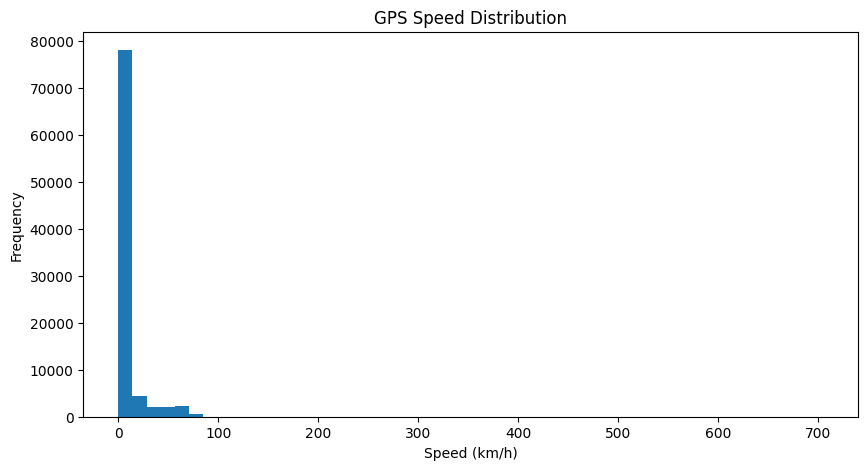

In [111]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
test_100_df["speed_kmh"].dropna().plot(
    kind="hist",
    bins=50
)
plt.xlabel("Speed (km/h)")
plt.ylabel("Frequency")
plt.title("GPS Speed Distribution")
plt.show()

# High Speed Inspect 

In [112]:
test_100_df[
    test_100_df["speed_kmh"] > 100
][
    [
        "entity_id",
        "timestamp",
        "latitude",
        "longitude",
        "distance_meters",
        "time_diff_seconds",
        "speed_kmh"
    ]
].head(20)

,entity_id,timestamp,latitude,longitude,distance_meters,time_diff_seconds,speed_kmh
150,000,2008-10-23 04:08:42,39.984397,116.299292,1179.814743,30.0,141.577769
3445,000,2008-10-29 09:30:38,39.991364,116.326605,360.944587,10.0,129.940051
5993,000,2008-11-10 03:31:12,39.976240,116.327436,140.536656,5.0,101.186392
7769,000,2008-11-12 02:51:48,39.999390,116.325337,232.380809,6.0,139.428485
7852,000,2008-11-12 03:33:03,40.000180,116.323727,490.678878,6.0,294.407327
8740,000,2008-11-13 14:04:16,40.010026,116.322920,266.864495,5.0,192.142436
9302,000,2008-11-14 11:18:39,40.008733,116.321315,173.819814,5.0,125.150266
9644,000,2008-11-15 04:00:13,40.009945,116.322726,971.756693,8.0,437.290512
11091,000,2008-11-22 01:44:24,40.020527,116.308791,171.075684,5.0,123.174492
11101,000,2008-11-22 01:45:14,40.012928,116.315945,154.886806,5.0,111.518500


# Gps Jump Detection 

In [113]:
test_100_df["gps_jump"] = (
    test_100_df["distance_meters"] > 1000
)
print(
    "Potential GPS jumps:",
    test_100_df["gps_jump"].sum()
)

Potential GPS jumps: 30


## 6. Visual Exploratory Data Analysis

Visual EDA is performed to understand GPS movement patterns before
building anomaly-detection features and models.

We analyze:
1. GPS trajectories
2. Speed distribution
3. Time-gap distribution
4. Distance distribution
5. Per-user movement behavior
6. GPS jumps
7. Missing and duplicate records

In [114]:
# Select one entity for trajectory visualization

sample_entity = test_100_df["entity_id"].iloc[0]

entity_df = test_100_df[
    test_100_df["entity_id"] == sample_entity
].copy()

print("Entity:", sample_entity)
print("Number of GPS points:", len(entity_df))
print("Time range:")
print(entity_df["timestamp"].min())
print(entity_df["timestamp"].max())

Entity: 000
Number of GPS points: 89252
Time range:
2008-10-23 02:53:04
2009-05-12 10:04:01


# Simple Gps Trajectory Plot 

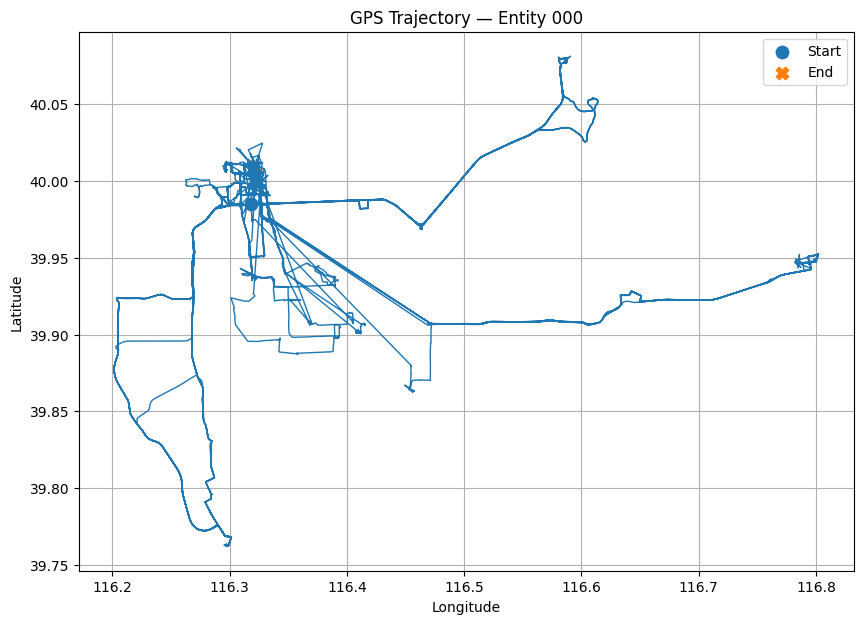

In [115]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 7))
plt.plot(
    entity_df["longitude"],
    entity_df["latitude"],
    linewidth=1
)
plt.scatter(
    entity_df["longitude"].iloc[0],
    entity_df["latitude"].iloc[0],
    marker="o",
    s=80,
    label="Start"
)
plt.scatter(
    entity_df["longitude"].iloc[-1],
    entity_df["latitude"].iloc[-1],
    marker="X",
    s=80,
    label="End"
)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"GPS Trajectory — Entity {sample_entity}")
plt.legend()
plt.grid(True)
plt.show()

**Important:** An unusual shape in a GPS trajectory does not automatically indicate a guard anomaly; it could also be caused by GPS errors.

# Speed Distribution 

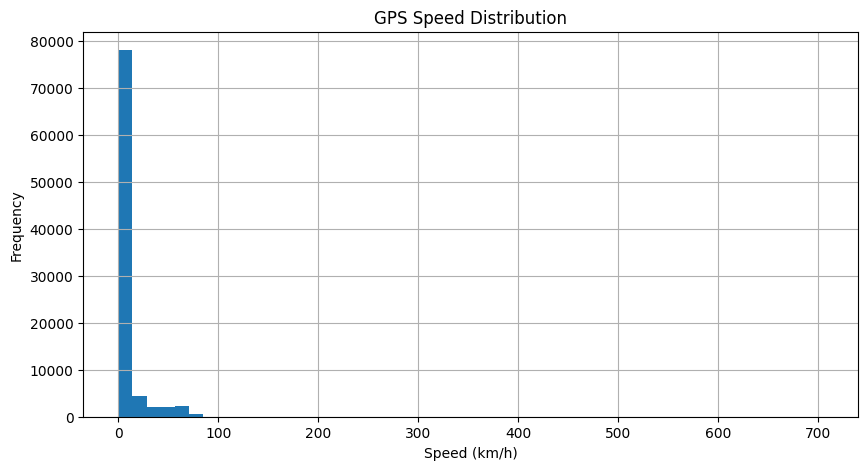

In [116]:
plt.figure(figsize=(10, 5))
test_100_df["speed_kmh"].dropna().plot(
    kind="hist",
    bins=50
)
plt.xlabel("Speed (km/h)")
plt.ylabel("Frequency")
plt.title("GPS Speed Distribution")
plt.grid(True)
plt.show()

# Percentile Speed 

In [117]:
speed_percentiles = test_100_df[
    "speed_kmh"
].dropna().quantile(
    [0.50, 0.75, 0.90, 0.95, 0.99, 0.999]
)
print(speed_percentiles)

0.500     1.892427
0.750     6.317760
0.900    18.405980
0.950    45.212683
0.990    68.413034
0.999    82.925674
Name: speed_kmh, dtype: float64


# Time Gap Distribution 

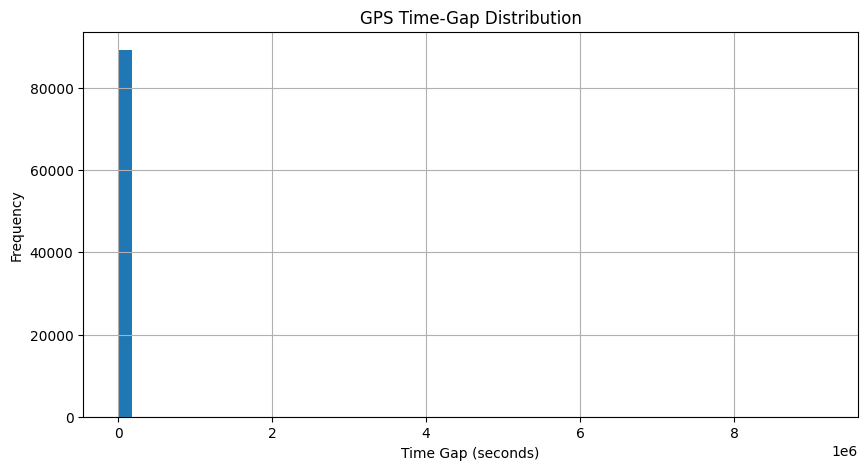

In [118]:
plt.figure(figsize=(10, 5))
test_100_df[
    "time_diff_seconds"
].dropna().plot(
    kind="hist",
    bins=50
)
plt.xlabel("Time Gap (seconds)")
plt.ylabel("Frequency")
plt.title("GPS Time-Gap Distribution")
plt.grid(True)
plt.show()

# Time Gap Statistics 

In [119]:
test_100_df[
    "time_diff_seconds"
].describe(
    percentiles=[
        0.50,
        0.75,
        0.90,
        0.95,
        0.99
    ]
)

count    8.925100e+04
mean     1.948690e+02
std      3.093480e+04
min      1.000000e+00
50%      5.000000e+00
75%      5.000000e+00
90%      5.000000e+00
95%      5.000000e+00
99%      1.000000e+01
max      9.156457e+06
Name: time_diff_seconds, dtype: float64

In [120]:
large_gaps = test_100_df[
    test_100_df["time_diff_seconds"] > 300
].copy()

print("Gaps > 5 minutes:", len(large_gaps))

large_gaps[
    [
        "entity_id",
        "timestamp",
        "time_diff_seconds"
    ]
].head(20)

Gaps > 5 minutes: 420


,entity_id,timestamp,time_diff_seconds
148,000,2008-10-23 04:08:07,3772.0
470,000,2008-10-23 09:42:25,18453.0
606,000,2008-10-23 10:02:04,338.0
790,000,2008-10-23 10:26:35,319.0
873,000,2008-10-23 10:44:31,671.0
895,000,2008-10-23 11:08:22,1331.0
908,000,2008-10-24 02:09:59,53927.0
978,000,2008-10-24 02:21:54,385.0
1084,000,2008-10-24 02:41:31,725.0
1152,000,2008-10-26 13:44:07,212221.0


# Distance Distribution

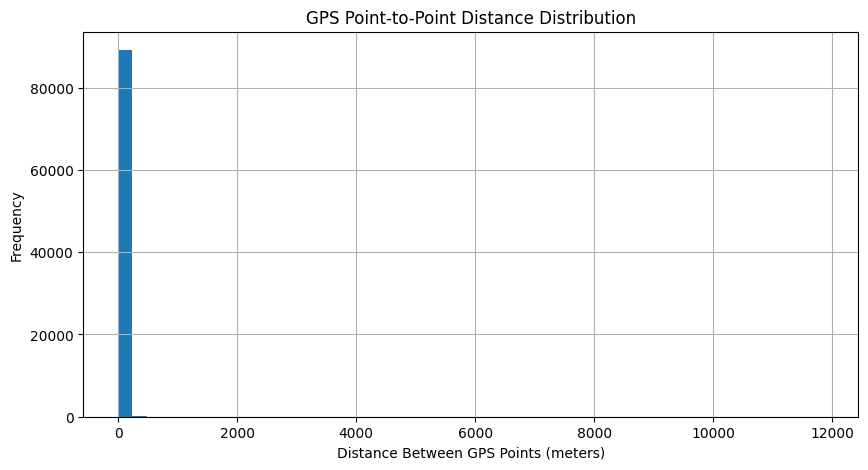

In [121]:
plt.figure(figsize=(10, 5))
test_100_df[
    "distance_meters"
].dropna().plot(
    kind="hist",
    bins=50
)
plt.xlabel("Distance Between GPS Points (meters)")
plt.ylabel("Frequency")
plt.title("GPS Point-to-Point Distance Distribution")
plt.grid(True)
plt.show()

# Distance Percentiles

In [122]:
distance_percentiles = test_100_df[
    "distance_meters"
].dropna().quantile(
    [0.50, 0.75, 0.90, 0.95, 0.99, 0.999]
)
print(distance_percentiles)

0.500      2.723752
0.750      9.198873
0.900     27.580458
0.950     65.030044
0.990     96.697309
0.999    315.255710
Name: distance_meters, dtype: float64


# Movements Per User 

In [123]:
user_summary = (
    test_100_df
    .groupby("entity_id")
    .agg(
        gps_points=("entity_id", "size"),
        total_distance_meters=("distance_meters", "sum"),
        average_speed_kmh=("speed_kmh", "mean"),
        max_speed_kmh=("speed_kmh", "max"),
        start_time=("timestamp", "min"),
        end_time=("timestamp", "max"),
    )
    .reset_index()
)

# Add Durations 

In [124]:
user_summary["duration_hours"] = (
    (
        user_summary["end_time"]
        - user_summary["start_time"]
    ).dt.total_seconds()
    / 3600
)

In [125]:
user_summary.head(10)

,entity_id,gps_points,total_distance_meters,average_speed_kmh,max_speed_kmh,start_time,end_time,duration_hours
0,000,89252,1.107559e+06,7.43926,704.500161,2008-10-23 02:53:04,2009-05-12 10:04:01,4831.1825


# Per-user Speed Comparison 

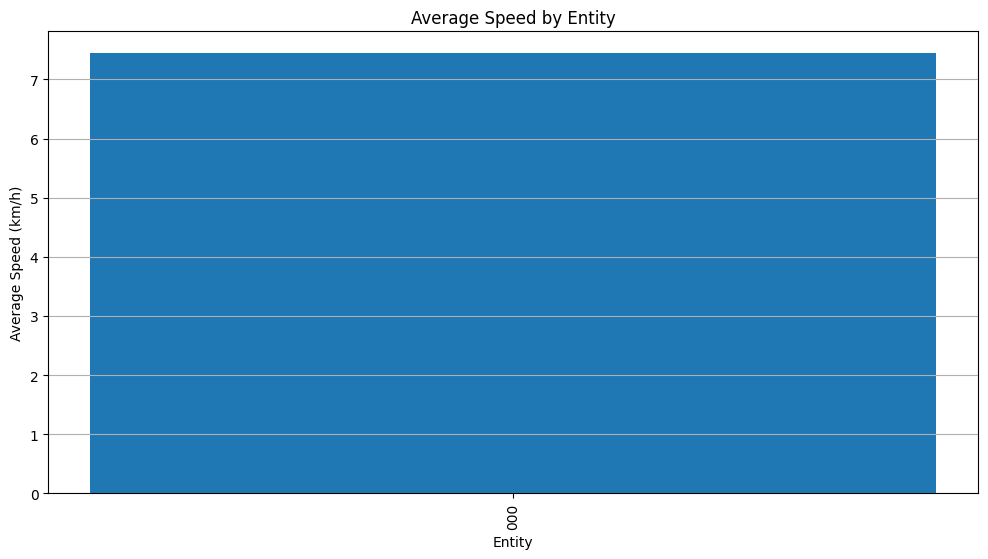

In [126]:
plt.figure(figsize=(12, 6))
plt.bar(
    user_summary["entity_id"].astype(str),
    user_summary["average_speed_kmh"]
)
plt.xlabel("Entity")
plt.ylabel("Average Speed (km/h)")
plt.title("Average Speed by Entity")
plt.xticks(rotation=90)
plt.grid(axis="y")
plt.show()

# Count gps-jumps

In [127]:
print(
    test_100_df["gps_jump"].value_counts()
)

gps_jump
False    89222
True        30
Name: count, dtype: int64


In [128]:
gps_jump_rate = (
    test_100_df["gps_jump"].mean() * 100
)

print(
    f"Potential GPS jump rate: {gps_jump_rate:.4f}%"
)

Potential GPS jump rate: 0.0336%


# Inspect Actual Gps Jumps

In [129]:
gps_jumps = test_100_df[
    test_100_df["gps_jump"]
].copy()

gps_jumps[
    [
        "entity_id",
        "timestamp",
        "latitude",
        "longitude",
        "distance_meters",
        "time_diff_seconds",
        "speed_kmh"
    ]
].head(20)

,entity_id,timestamp,latitude,longitude,distance_meters,time_diff_seconds,speed_kmh
148,000,2008-10-23 04:08:07,39.995777,116.286798,1011.070764,3772.0,0.964967
150,000,2008-10-23 04:08:42,39.984397,116.299292,1179.814743,30.0,141.577769
1152,000,2008-10-26 13:44:07,39.907414,116.370017,4168.701869,212221.0,0.070716
1795,000,2008-10-26 14:47:57,39.887811,116.358262,2454.897233,275.0,32.136837
1885,000,2008-10-26 14:59:47,39.921621,116.313330,1043.794125,75.0,50.102118
1947,000,2008-10-28 00:38:26,40.012290,116.297072,2108.918676,45152.0,0.168146
6137,000,2008-11-11 00:17:04,40.011824,116.297026,2556.728160,73852.0,0.124631
10939,000,2008-11-20 03:57:36,39.999738,116.322057,1853.379170,50860.0,0.131187
11089,000,2008-11-22 01:44:14,40.021469,116.305782,1245.199927,755.0,5.937377
11279,000,2008-11-22 05:50:55,39.986353,116.311987,1230.768548,700.0,6.329667


# Missing Values 

In [130]:
missing_summary = (
    test_100_df
    .isna()
    .sum()
    .sort_values(ascending=False)
)

print(missing_summary)

distance_meters      1
prev_longitude       1
prev_latitude        1
time_diff_seconds    1
speed_kmh            1
speed_mps            1
timestamp            0
entity_id            0
longitude            0
latitude             0
altitude_ft          0
gps_jump             0
dtype: int64


In [131]:
missing_percentage = (
    test_100_df.isna().mean() * 100
).sort_values(ascending=False)

print(missing_percentage)

distance_meters      0.00112
prev_longitude       0.00112
prev_latitude        0.00112
time_diff_seconds    0.00112
speed_kmh            0.00112
speed_mps            0.00112
timestamp            0.00000
entity_id            0.00000
longitude            0.00000
latitude             0.00000
altitude_ft          0.00000
gps_jump             0.00000
dtype: float64


In [132]:
duplicate_count = test_100_df.duplicated().sum()
print(
    "Duplicate rows:",
    duplicate_count
)

Duplicate rows: 0


# GPS-Specific Duplicate Check:

In [133]:
gps_duplicate_count = test_100_df.duplicated(
    subset=[
        "entity_id",
        "timestamp",
        "latitude",
        "longitude"
    ]
).sum()

print(
    "Duplicate GPS observations:",
    gps_duplicate_count
)

Duplicate GPS observations: 0


# Full GeoLife Batch Pipeline

In [134]:
from pathlib import Path

PROCESSED_DATA_DIR.mkdir(
    parents=True,
    exist_ok=True
)

GEOLIFE_OUTPUT_DIR = INTERIM_DATA_DIR / "geolife"

GEOLIFE_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Output directory:")
print(GEOLIFE_OUTPUT_DIR)

Output directory:
e:\Internship\Guard_Patrol_Anomaly_Detection\data\interim\geolife


In [135]:
BATCH_SIZE = 100

print("Total trajectory files:", len(trajectory_files))
print("Batch size:", BATCH_SIZE)

Total trajectory files: 18670
Batch size: 100


In [136]:
def process_geolife_batch(
    file_paths,
    batch_number
):
    """
    Process one batch of GeoLife trajectory files.
    """

    batch_dfs = []
    failed_files = []

    for file_path in file_paths:

        df = process_geolife_file(file_path)

        if df is not None and not df.empty:
            batch_dfs.append(df)
        else:
            failed_files.append(str(file_path))

    if not batch_dfs:
        return None, failed_files

    batch_df = pd.concat(
        batch_dfs,
        ignore_index=True
    )

    # Sort records
    batch_df = batch_df.sort_values(
        ["entity_id", "timestamp"]
    ).reset_index(drop=True)

    # Previous GPS point
    batch_df["prev_latitude"] = (
        batch_df
        .groupby("entity_id")["latitude"]
        .shift(1)
    )

    batch_df["prev_longitude"] = (
        batch_df
        .groupby("entity_id")["longitude"]
        .shift(1)
    )

    # Time difference
    batch_df["time_diff_seconds"] = (
        batch_df
        .groupby("entity_id")["timestamp"]
        .diff()
        .dt.total_seconds()
    )

    # Distance
    batch_df["distance_meters"] = haversine_distance(
        batch_df["prev_latitude"],
        batch_df["prev_longitude"],
        batch_df["latitude"],
        batch_df["longitude"],
    )

    # Speed
    batch_df["speed_mps"] = (
        batch_df["distance_meters"]
        / batch_df["time_diff_seconds"]
    )

    batch_df["speed_kmh"] = (
        batch_df["speed_mps"] * 3.6
    )

    # Data-quality flag
    batch_df["gps_jump"] = (
        batch_df["distance_meters"] > 1000
    )

    return batch_df, failed_files

## Test 1 batch 

In [137]:
first_batch_files = trajectory_files[:BATCH_SIZE]

batch_1_df, failed_files = process_geolife_batch(
    first_batch_files,
    batch_number=1
)

print("Batch rows:", len(batch_1_df))
print("Failed files:", len(failed_files))

Batch rows: 89252
Failed files: 0


In [138]:
batch_1_df.head()

,entity_id,timestamp,latitude,longitude,altitude_ft,prev_latitude,prev_longitude,time_diff_seconds,distance_meters,speed_mps,speed_kmh,gps_jump
0,000,2008-10-23 02:53:04,39.984702,116.318417,492,NaN,NaN,NaN,NaN,NaN,NaN,False
1,000,2008-10-23 02:53:10,39.984683,116.318450,492,39.984702,116.318417,6.0,2.811820,0.468637,1.687092,False
2,000,2008-10-23 02:53:15,39.984686,116.318417,492,39.984683,116.318450,5.0,2.811585,0.562317,2.024341,False
3,000,2008-10-23 02:53:20,39.984688,116.318385,492,39.984686,116.318417,5.0,2.726382,0.545276,1.962995,False
4,000,2008-10-23 02:53:25,39.984655,116.318263,492,39.984688,116.318385,5.0,10.394521,2.078904,7.484055,False


In [139]:
batch_1_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89252 entries, 0 to 89251
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   entity_id          89252 non-null  object        
 1   timestamp          89252 non-null  datetime64[ns]
 2   latitude           89252 non-null  float64       
 3   longitude          89252 non-null  float64       
 4   altitude_ft        89252 non-null  int64         
 5   prev_latitude      89251 non-null  float64       
 6   prev_longitude     89251 non-null  float64       
 7   time_diff_seconds  89251 non-null  float64       
 8   distance_meters    89251 non-null  float64       
 9   speed_mps          89251 non-null  float64       
 10  speed_kmh          89251 non-null  float64       
 11  gps_jump           89252 non-null  bool          
dtypes: bool(1), datetime64[ns](1), float64(8), int64(1), object(1)
memory usage: 7.6+ MB


# Save Batch in Parquet

In [140]:
batch_output_path = (
    GEOLIFE_OUTPUT_DIR
    / "geolife_batch_001.parquet"
)

batch_1_df.to_parquet(
    batch_output_path,
    index=False
)

print("Saved:")
print(batch_output_path)

Saved:
e:\Internship\Guard_Patrol_Anomaly_Detection\data\interim\geolife\geolife_batch_001.parquet


In [141]:
verification_df = pd.read_parquet(
    batch_output_path
)
print("Rows:", len(verification_df))
print("Columns:", verification_df.columns.tolist())

Rows: 89252
Columns: ['entity_id', 'timestamp', 'latitude', 'longitude', 'altitude_ft', 'prev_latitude', 'prev_longitude', 'time_diff_seconds', 'distance_meters', 'speed_mps', 'speed_kmh', 'gps_jump']


In [142]:
print("Missing values:")
print(
    batch_1_df.isna().sum()
)

Missing values:
entity_id            0
timestamp            0
latitude             0
longitude            0
altitude_ft          0
prev_latitude        1
prev_longitude       1
time_diff_seconds    1
distance_meters      1
speed_mps            1
speed_kmh            1
gps_jump             0
dtype: int64


In [143]:
print(
    "GPS jumps:",
    batch_1_df["gps_jump"].sum()
)

GPS jumps: 30


In [144]:
print(
    "Unique entities:",
    batch_1_df["entity_id"].nunique()
)

Unique entities: 1


## Log of Failed Files 

In [145]:
FAILED_LOG_PATH = (
    GEOLIFE_OUTPUT_DIR / "failed_files.txt")
with open(
    FAILED_LOG_PATH,
    "w",
    encoding="utf-8"
) as f:
    for file_path in failed_files:
        f.write(file_path + "\n")

print("Failed-file log saved:")
print(FAILED_LOG_PATH)

Failed-file log saved:
e:\Internship\Guard_Patrol_Anomaly_Detection\data\interim\geolife\failed_files.txt


# Run Full PipeLine

In [146]:
import gc
import time
total_files = len(trajectory_files)
successful_batches = 0
total_failed_files = []
start_time = time.time()
for start in range(
    0,
    total_files,
    BATCH_SIZE
):
    end = min(
        start + BATCH_SIZE,
        total_files
    )
    batch_number = (
        start // BATCH_SIZE
    ) + 1
    current_files = trajectory_files[
        start:end
    ]
    print(
        f"\nProcessing batch {batch_number}"
        f" | files {start + 1}-{end}"
        f" / {total_files}"
    )
    batch_df, failed = process_geolife_batch(
        current_files,
        batch_number
    )
    total_failed_files.extend(failed)
    if batch_df is None:
        print("No valid records in this batch.")
        continue
    output_path = (
        GEOLIFE_OUTPUT_DIR
        / f"geolife_batch_{batch_number:03d}.parquet"
    )
    batch_df.to_parquet(
        output_path,
        index=False
    )
    successful_batches += 1
    print(
        f"Saved {len(batch_df):,} rows"
    )
    # Release memory
    del batch_df
    gc.collect()
elapsed = time.time() - start_time
print("\nProcessing completed.")
print("Successful batches:", successful_batches)
print("Failed files:", len(total_failed_files))
print(f"Time taken: {elapsed / 60:.2f} minutes")


Processing batch 1 | files 1-100 / 18670
Saved 89,252 rows

Processing batch 2 | files 101-200 / 18670
Saved 135,321 rows

Processing batch 3 | files 201-300 / 18670
Saved 167,527 rows

Processing batch 4 | files 301-400 / 18670
Saved 123,523 rows

Processing batch 5 | files 401-500 / 18670
Saved 156,508 rows

Processing batch 6 | files 501-600 / 18670
Saved 157,618 rows

Processing batch 7 | files 601-700 / 18670
Saved 130,889 rows

Processing batch 8 | files 701-800 / 18670
Saved 106,739 rows

Processing batch 9 | files 801-900 / 18670
Saved 95,987 rows

Processing batch 10 | files 901-1000 / 18670
Saved 152,816 rows

Processing batch 11 | files 1001-1100 / 18670
Saved 101,885 rows

Processing batch 12 | files 1101-1200 / 18670
Saved 139,632 rows

Processing batch 13 | files 1201-1300 / 18670
Saved 124,727 rows

Processing batch 14 | files 1301-1400 / 18670
Saved 198,369 rows

Processing batch 15 | files 1401-1500 / 18670
Saved 638,298 rows

Processing batch 16 | files 1501-1600 / 1

KeyboardInterrupt: 

## 7. Full GeoLife Dataset Validation

The complete GeoLife trajectory dataset has been processed in batches.

This section validates:
- total processed files
- total GPS observations
- unique users
- temporal coverage
- geographic coverage
- missing values
- duplicate observations
- GPS quality

# Send Parquet Files

In [ ]:
GEOLIFE_BATCH_FILES = sorted(
    GEOLIFE_OUTPUT_DIR.glob("geolife_batch_*.parquet")
)

print(
    "Number of batch files:",
    len(GEOLIFE_BATCH_FILES)
)

Number of batch files: 187


# Count Rows in dataset

In [ ]:
import pyarrow.parquet as pq  ## read metadata
total_rows = 0
for file_path in GEOLIFE_BATCH_FILES:
    metadata = pq.ParquetFile(file_path).metadata
    total_rows += metadata.num_rows

print(f"Total GPS observations: {total_rows:,}")

Total GPS observations: 24,876,977


# Verify Schema

In [ ]:
import pandas as pd
schema_df = pd.read_parquet(
    GEOLIFE_BATCH_FILES[0]
)
print(schema_df.dtypes)

entity_id                    object
timestamp            datetime64[ns]
latitude                    float64
longitude                   float64
altitude_ft                   int64
prev_latitude               float64
prev_longitude              float64
time_diff_seconds           float64
distance_meters             float64
speed_mps                   float64
speed_kmh                   float64
gps_jump                       bool
dtype: object


# GeoGraphic Coverage

In [ ]:
min_lat = float("inf")
max_lat = float("-inf")
min_lon = float("inf")
max_lon = float("-inf")

for file_path in GEOLIFE_BATCH_FILES:

    df = pd.read_parquet(
        file_path,
        columns=[
            "latitude",
            "longitude"
        ]
    )

    min_lat = min(min_lat, df["latitude"].min())
    max_lat = max(max_lat, df["latitude"].max())

    min_lon = min(min_lon, df["longitude"].min())
    max_lon = max(max_lon, df["longitude"].max())

    del df

print("Latitude:", min_lat, "→", max_lat)
print("Longitude:", min_lon, "→", max_lon)

Latitude: 1.044024 → 64.751993
Longitude: -179.9695933 → 179.9969416


# Geolife GPS geographic extent

In [ ]:
from pathlib import Path
import pandas as pd

# Project paths
PROJECT_DIR = Path.cwd().parent

INTERIM_DATA_DIR = PROJECT_DIR / "data" / "interim"
GEOLIFE_OUTPUT_DIR = INTERIM_DATA_DIR / "geolife"

print("Geolife output directory:")
print(GEOLIFE_OUTPUT_DIR)

print("\nBatch files:")
for file in list(GEOLIFE_OUTPUT_DIR.glob("*.parquet"))[:5]:
    print(file.name)

Geolife output directory:
e:\Internship\Guard_Patrol_Anomaly_Detection\data\interim\geolife

Batch files:
geolife_batch_001.parquet
geolife_batch_002.parquet
geolife_batch_003.parquet
geolife_batch_004.parquet
geolife_batch_005.parquet


In [ ]:
import pandas as pd
sample_batch = pd.read_parquet(
    sorted(GEOLIFE_OUTPUT_DIR.glob("*.parquet"))[0]
)
sample_batch.head()

,entity_id,timestamp,latitude,longitude,altitude_ft,prev_latitude,prev_longitude,time_diff_seconds,distance_meters,speed_mps,speed_kmh,gps_jump
0,000,2008-10-23 02:53:04,39.984702,116.318417,492,NaN,NaN,NaN,NaN,NaN,NaN,False
1,000,2008-10-23 02:53:10,39.984683,116.318450,492,39.984702,116.318417,6.0,2.811820,0.468637,1.687092,False
2,000,2008-10-23 02:53:15,39.984686,116.318417,492,39.984683,116.318450,5.0,2.811585,0.562317,2.024341,False
3,000,2008-10-23 02:53:20,39.984688,116.318385,492,39.984686,116.318417,5.0,2.726382,0.545276,1.962995,False
4,000,2008-10-23 02:53:25,39.984655,116.318263,492,39.984688,116.318385,5.0,10.394521,2.078904,7.484055,False


In [ ]:
print(sample_batch.columns.tolist())

['entity_id', 'timestamp', 'latitude', 'longitude', 'altitude_ft', 'prev_latitude', 'prev_longitude', 'time_diff_seconds', 'distance_meters', 'speed_mps', 'speed_kmh', 'gps_jump']


In [ ]:
import pandas as pd
min_lat = float("inf")
max_lat = float("-inf")
min_lon = float("inf")
max_lon = float("-inf")

batch_files = sorted(GEOLIFE_OUTPUT_DIR.glob("*.parquet"))

print("Total batch files:", len(batch_files))

for i, file in enumerate(batch_files, start=1):

    df = pd.read_parquet(
        file,
        columns=["latitude", "longitude"]
    )

    df = df.dropna(subset=["latitude", "longitude"])

    min_lat = min(min_lat, df["latitude"].min())
    max_lat = max(max_lat, df["latitude"].max())

    min_lon = min(min_lon, df["longitude"].min())
    max_lon = max(max_lon, df["longitude"].max())

print("\nActual Geolife GPS extent:")
print("Min latitude :", min_lat)
print("Max latitude :", max_lat)
print("Min longitude:", min_lon)
print("Max longitude:", max_lon)

Total batch files: 187

Actual Geolife GPS extent:
Min latitude : 1.044024
Max latitude : 64.751993
Min longitude: -179.9695933
Max longitude: 179.9969416


# Identify  Occupied Tiles

In [ ]:
import pandas as pd
import numpy as np
TILE_SIZE = 0.01
occupied_tiles = set()
for i, file in enumerate(batch_files, start=1):
    df = pd.read_parquet(
        file,
        columns=["latitude", "longitude"]
    )
    df = df.dropna(subset=["latitude", "longitude"])

    df["lat_tile"] = np.floor(
        df["latitude"] / TILE_SIZE
    ).astype(int)

    df["lon_tile"] = np.floor(
        df["longitude"] / TILE_SIZE
    ).astype(int)

    occupied_tiles.update(
        zip(
            df["lat_tile"],
            df["lon_tile"]
        )
    )

print("Occupied GPS tiles:", len(occupied_tiles))

Occupied GPS tiles: 85073


# Inspect Occupied Tiles

In [ ]:
occupied_tiles = sorted(occupied_tiles)
for tile in occupied_tiles[:20]:
    print(tile)

(104, 10350)
(104, 10351)
(104, 10352)
(104, 10353)
(104, 10354)
(104, 10355)
(104, 10356)
(104, 10377)
(104, 10378)
(105, 10348)
(105, 10349)
(105, 10350)
(105, 10356)
(105, 10357)
(105, 10358)
(105, 10359)
(105, 10360)
(105, 10361)
(105, 10362)
(105, 10375)


# Configure OSMnx 

# Road Network Download

In [ ]:
%pip install osmnx

In [ ]:
import osmnx as ox

ox.settings.use_cache = True
ox.settings.requests_timeout = 300

print("OSMnx configured.")

OSMnx configured.


# GPS-based OSM tile

In [ ]:
# Now we will map one occupied Tile 
lat_tile, lon_tile = occupied_tiles[0]

south = lat_tile * TILE_SIZE
north = (lat_tile + 1) * TILE_SIZE

west = lon_tile * TILE_SIZE
east = (lon_tile + 1) * TILE_SIZE

bbox = (
    west,
    south,
    east,
    north
)

print("OSM bbox:")
print(bbox)      
## west, south, east, north

OSM bbox:
(103.5, 1.04, 103.51, 1.05)


In [ ]:
print(bbox)
print(
    "South:", south,
    "North:", north,
    "West:", west,
    "East:", east
)

(103.5, 1.04, 103.51, 1.05)
South: 1.04 North: 1.05 West: 103.5 East: 103.51


# Occupied Tiles Frequency 

In [ ]:
from collections import Counter
import pandas as pd
import numpy as np
TILE_SIZE = 0.01
tile_counts = Counter()
for i, file in enumerate(batch_files, start=1):
    df = pd.read_parquet(
        file,
        columns=["latitude", "longitude"]
    )
    df = df.dropna(
        subset=["latitude", "longitude"]
    )
    df["lat_tile"] = np.floor(
        df["latitude"] / TILE_SIZE
    ).astype(int)

    df["lon_tile"] = np.floor(
        df["longitude"] / TILE_SIZE
    ).astype(int)

    tiles = zip(
        df["lat_tile"],
        df["lon_tile"]
    )

    tile_counts.update(tiles)

print("Total unique tiles:", len(tile_counts))

Total unique tiles: 85073


# Top 20 GPS Dense Areas

In [ ]:
top_tiles = tile_counts.most_common(20)
for rank, (tile, count) in enumerate(top_tiles, start=1):
    lat_tile, lon_tile = tile
    print(
        f"{rank:02d}. "
        f"Tile={tile} | "
        f"GPS points={count:,}"
    )

01. Tile=(3997, 11633) | GPS points=943,375
02. Tile=(3999, 11632) | GPS points=580,734
03. Tile=(3998, 11632) | GPS points=580,574
04. Tile=(3997, 11632) | GPS points=566,483
05. Tile=(4000, 11632) | GPS points=519,454
06. Tile=(3997, 11630) | GPS points=370,691
07. Tile=(3998, 11630) | GPS points=370,158
08. Tile=(3997, 11631) | GPS points=321,709
09. Tile=(4000, 11631) | GPS points=319,283
10. Tile=(3996, 11641) | GPS points=230,814
11. Tile=(3998, 11635) | GPS points=224,402
12. Tile=(4007, 11632) | GPS points=208,665
13. Tile=(3999, 11633) | GPS points=203,607
14. Tile=(3998, 11634) | GPS points=197,070
15. Tile=(3998, 11633) | GPS points=191,671
16. Tile=(3996, 11630) | GPS points=187,495
17. Tile=(3998, 11631) | GPS points=174,948
18. Tile=(3997, 11641) | GPS points=173,609
19. Tile=(3999, 11641) | GPS points=171,908
20. Tile=(3998, 11641) | GPS points=168,458


Convert Tiles Into Coordinates 

In [ ]:
for rank, (tile, count) in enumerate(
    top_tiles,
    start=1
):
    lat_tile, lon_tile = tile
    south = lat_tile * TILE_SIZE
    north = (lat_tile + 1) * TILE_SIZE
    west = lon_tile * TILE_SIZE
    east = (lon_tile + 1) * TILE_SIZE
    print(
        f"{rank:02d}. "
        f"GPS points={count:,} | "
        f"Lat={south:.2f}–{north:.2f} | "
        f"Lon={west:.2f}–{east:.2f}"
    )

01. GPS points=943,375 | Lat=39.97–39.98 | Lon=116.33–116.34
02. GPS points=580,734 | Lat=39.99–40.00 | Lon=116.32–116.33
03. GPS points=580,574 | Lat=39.98–39.99 | Lon=116.32–116.33
04. GPS points=566,483 | Lat=39.97–39.98 | Lon=116.32–116.33
05. GPS points=519,454 | Lat=40.00–40.01 | Lon=116.32–116.33
06. GPS points=370,691 | Lat=39.97–39.98 | Lon=116.30–116.31
07. GPS points=370,158 | Lat=39.98–39.99 | Lon=116.30–116.31
08. GPS points=321,709 | Lat=39.97–39.98 | Lon=116.31–116.32
09. GPS points=319,283 | Lat=40.00–40.01 | Lon=116.31–116.32
10. GPS points=230,814 | Lat=39.96–39.97 | Lon=116.41–116.42
11. GPS points=224,402 | Lat=39.98–39.99 | Lon=116.35–116.36
12. GPS points=208,665 | Lat=40.07–40.08 | Lon=116.32–116.33
13. GPS points=203,607 | Lat=39.99–40.00 | Lon=116.33–116.34
14. GPS points=197,070 | Lat=39.98–39.99 | Lon=116.34–116.35
15. GPS points=191,671 | Lat=39.98–39.99 | Lon=116.33–116.34
16. GPS points=187,495 | Lat=39.96–39.97 | Lon=116.30–116.31
17. GPS points=174,948 |

In [ ]:
import pandas as pd
from pathlib import Path
coverage_rows = []
for tile, count in tile_counts.items():
    lat_tile, lon_tile = tile
    south = lat_tile * TILE_SIZE
    north = (lat_tile + 1) * TILE_SIZE
    west = lon_tile * TILE_SIZE
    east = (lon_tile + 1) * TILE_SIZE
    coverage_rows.append({
        "lat_tile": lat_tile,
        "lon_tile": lon_tile,
        "south": south,
        "north": north,
        "west": west,
        "east": east,
        "gps_points": count
    })
coverage_df = pd.DataFrame(coverage_rows)
coverage_df = coverage_df.sort_values(
    "gps_points",
    ascending=False
).reset_index(drop=True)
coverage_df.head(20)

,lat_tile,lon_tile,south,north,west,east,gps_points
0,3997,11633,39.97,39.98,116.33,116.34,943375
1,3999,11632,39.99,40.00,116.32,116.33,580734
2,3998,11632,39.98,39.99,116.32,116.33,580574
3,3997,11632,39.97,39.98,116.32,116.33,566483
4,4000,11632,40.00,40.01,116.32,116.33,519454
5,3997,11630,39.97,39.98,116.30,116.31,370691
6,3998,11630,39.98,39.99,116.30,116.31,370158
7,3997,11631,39.97,39.98,116.31,116.32,321709
8,4000,11631,40.00,40.01,116.31,116.32,319283
9,3996,11641,39.96,39.97,116.41,116.42,230814


## Calculate Percentile 

In [ ]:
total_gps_points = coverage_df["gps_points"].sum()

coverage_df["percentage"] = (
    coverage_df["gps_points"] /
    total_gps_points
) * 100

coverage_df.head(20)

,lat_tile,lon_tile,south,north,west,east,gps_points,percentage
0,3997,11633,39.97,39.98,116.33,116.34,943375,3.792161
1,3999,11632,39.99,40.00,116.32,116.33,580734,2.334424
2,3998,11632,39.98,39.99,116.32,116.33,580574,2.333780
3,3997,11632,39.97,39.98,116.32,116.33,566483,2.277138
4,4000,11632,40.00,40.01,116.32,116.33,519454,2.088091
5,3997,11630,39.97,39.98,116.30,116.31,370691,1.490097
6,3998,11630,39.98,39.99,116.30,116.31,370158,1.487954
7,3997,11631,39.97,39.98,116.31,116.32,321709,1.293200
8,4000,11631,40.00,40.01,116.31,116.32,319283,1.283448
9,3996,11641,39.96,39.97,116.41,116.42,230814,0.927822


# Top 20 in Readable Form

In [ ]:
print(
    coverage_df[
        [
            "south",
            "north",
            "west",
            "east",
            "gps_points",
            "percentage"
        ]
    ].head(20).to_string(index=False)
)

 south  north   west   east  gps_points  percentage
 39.97  39.98 116.33 116.34      943375    3.792161
 39.99  40.00 116.32 116.33      580734    2.334424
 39.98  39.99 116.32 116.33      580574    2.333780
 39.97  39.98 116.32 116.33      566483    2.277138
 40.00  40.01 116.32 116.33      519454    2.088091
 39.97  39.98 116.30 116.31      370691    1.490097
 39.98  39.99 116.30 116.31      370158    1.487954
 39.97  39.98 116.31 116.32      321709    1.293200
 40.00  40.01 116.31 116.32      319283    1.283448
 39.96  39.97 116.41 116.42      230814    0.927822
 39.98  39.99 116.35 116.36      224402    0.902047
 40.07  40.08 116.32 116.33      208665    0.838788
 39.99  40.00 116.33 116.34      203607    0.818456
 39.98  39.99 116.34 116.35      197070    0.792178
 39.98  39.99 116.33 116.34      191671    0.770475
 39.96  39.97 116.30 116.31      187495    0.753689
 39.98  39.99 116.31 116.32      174948    0.703253
 39.97  39.98 116.41 116.42      173609    0.697870
 39.99  40.0

# Save Coverage File

In [ ]:
COVERAGE_OUTPUT = (
    INTERIM_DATA_DIR /
    "geolife_gps_spatial_coverage.csv"
)
coverage_df.to_csv(
    COVERAGE_OUTPUT,
    index=False
)
print("Saved:")
print(COVERAGE_OUTPUT)

Saved:
e:\Internship\Guard_Patrol_Anomaly_Detection\data\interim\geolife_gps_spatial_coverage.csv


In [ ]:
coverage_df.head(20)

,lat_tile,lon_tile,south,north,west,east,gps_points,percentage
0,3997,11633,39.97,39.98,116.33,116.34,943375,3.792161
1,3999,11632,39.99,40.00,116.32,116.33,580734,2.334424
2,3998,11632,39.98,39.99,116.32,116.33,580574,2.333780
3,3997,11632,39.97,39.98,116.32,116.33,566483,2.277138
4,4000,11632,40.00,40.01,116.32,116.33,519454,2.088091
5,3997,11630,39.97,39.98,116.30,116.31,370691,1.490097
6,3998,11630,39.98,39.99,116.30,116.31,370158,1.487954
7,3997,11631,39.97,39.98,116.31,116.32,321709,1.293200
8,4000,11631,40.00,40.01,116.31,116.32,319283,1.283448
9,3996,11641,39.96,39.97,116.41,116.42,230814,0.927822


## OSM Road Network Download

In [ ]:
G = ox.graph.graph_from_bbox(
    bbox=bbox,
    network_type="walk",
    simplify=True,
    retain_all=False
)

print("Nodes:", len(G.nodes))
print("Edges:", len(G.edges))

# Define OSM path 

In [ ]:
from pathlib import Path

OSM_RAW_DIR = (
    PROJECT_DIR
    / "data"
    / "raw"
    / "osm"
)

OSM_PBF_PATH = (
    OSM_RAW_DIR
    / "beijing-latest.osm.pbf"
)

print("OSM file:")
print(OSM_PBF_PATH)
print("Exists:", OSM_PBF_PATH.exists())

OSM file:
e:\Internship\Guard_Patrol_Anomaly_Detection\data\raw\osm\beijing-latest.osm.pbf
Exists: True


# Verify File Size

In [ ]:
file_size_mb = (
    OSM_PBF_PATH.stat().st_size
    / (1024 ** 2)
)

print(f"OSM file size: {file_size_mb:.2f} MB")

OSM file size: 34.86 MB


# Check Road Network 

In [ ]:
%pip install pyrosm

Defaulting to user installation because normal site-packages is not writeable
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached protobuf-7.35.1-cp310-abi3-win_amd64.whl.metadata (595 bytes)
   ---------------------------------------- 0.0/3.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/3.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/3.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/3.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/3.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/3.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/3.1 MB ? eta -:--:--
   -----------------------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.53.1 requires protobuf<7,>=3.20, but you have protobuf 7.35.1 which is incompatible.


In [ ]:
from pyrosm import OSM
osm = OSM(str(OSM_PBF_PATH))

print("OSM PBF loaded successfully.")

OSM PBF loaded successfully.


In [ ]:
roads = osm.get_network(
    network_type="walking"
)
print("Road segments:", len(roads))
print("Columns:")
print(roads.columns.tolist())

Road segments: 246502
Columns:
['access', 'area', 'bicycle', 'bicycle_road', 'bridge', 'cycleway', 'est_width', 'foot', 'footway', 'highway', 'int_ref', 'junction', 'lanes', 'lit', 'maxspeed', 'motorcar', 'motorroad', 'motor_vehicle', 'name', 'oneway', 'oneway:bicycle', 'overtaking', 'psv', 'ref', 'service', 'segregated', 'sidewalk', 'smoothness', 'surface', 'tracktype', 'tunnel', 'turn', 'width', 'id', 'timestamp', 'version', 'tags', 'osm_type', 'geometry', 'length']


In [ ]:
print(roads.head())

  access  area bicycle bicycle_road bridge cycleway est_width          foot  \
0   None  None    None         None   None     None      None          None   
1    yes  None     yes         None   None     None      None  use_sidepath   
2   None  None    None         None   None     None      None          None   
3   None  None    None         None   None     None      None          None   
4   None  None    None         None   None     None      None          None   

  footway    highway  ... tunnel  turn width       id   timestamp version  \
0    None  secondary  ...   None  None  None  4231222  1740822820      26   
1    None  secondary  ...   None  None    30  4231223  1740822820      36   
2    None      trunk  ...   None  None  None  4263917  1739242379      37   
3    None   tertiary  ...   None  None  None  4263918  1771225499      21   
4    None   tertiary  ...   None  None  None  4484480  1738420853      15   

                                                tags osm_type 

In [ ]:
print(roads.shape)

(246502, 40)


In [ ]:
print(roads.shape)

(246502, 40)


In [ ]:
print(roads.geometry.iloc[0])

MULTILINESTRING ((116.38943 39.9062601, 116.3894463 39.9060159))


# Verify GeoLife OSM CRS

In [ ]:
print("OSM CRS:", roads.crs)

OSM CRS: epsg:4326


## Save Beijing road network

In [ ]:
OSM_INTERIM_DIR = (
    PROJECT_DIR
    / "data"
    / "interim"
    / "osm")
OSM_INTERIM_DIR.mkdir(
    parents=True,
    exist_ok=True)
roads_output = (
    OSM_INTERIM_DIR
    / "beijing_walking_network.gpkg")

roads.to_file(
    roads_output,
    driver="GPKG")

print("Saved:", roads_output)

Saved: e:\Internship\Guard_Patrol_Anomaly_Detection\data\interim\osm\beijing_walking_network.gpkg


# Visualization

Text(0.5, 1.0, 'Beijing OSM Walking Network')

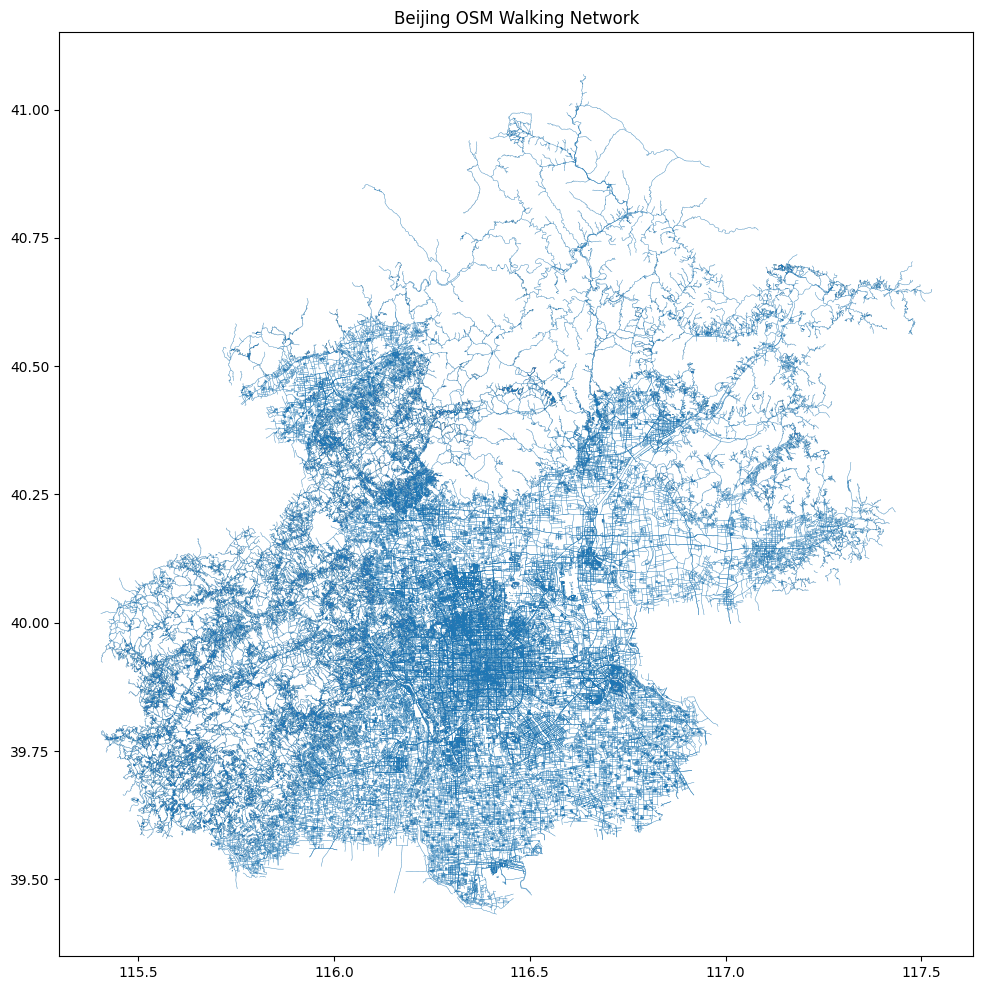

In [ ]:
ax = roads.plot(
    figsize=(12, 12),
    linewidth=0.3
)
ax.set_title(
    "Beijing OSM Walking Network"
)

# Gps Points -> OSM Road Matching

OSM geometry also needs proper CRS handling.

For geospatial calculations we should not blindly calculate distances using latitude/longitude degrees.

In [ ]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

# Load Saved OSM 

In [ ]:
import geopandas as gpd
roads = gpd.read_file(
    OSM_INTERIM_DIR / "beijing_walking_network.gpkg"
)
print("Road segments:", len(roads))
print("CRS:", roads.crs)

Road segments: 246502
CRS: EPSG:4326


## Define Path Again 

In [147]:
from pathlib import Path

PROJECT_DIR = Path.cwd().parent

RAW_DATA_DIR = PROJECT_DIR / "data" / "raw"
INTERIM_DATA_DIR = PROJECT_DIR / "data" / "interim"
PROCESSED_DATA_DIR = PROJECT_DIR / "data" / "processed"

GEOLIFE_DIR = RAW_DATA_DIR / "Geolife Trajectories 1.3"
GEOLIFE_DATA_DIR = GEOLIFE_DIR / "Data"

print("Project:", PROJECT_DIR)
print("Geolife:", GEOLIFE_DATA_DIR)

Project: e:\Internship\Guard_Patrol_Anomaly_Detection
Geolife: e:\Internship\Guard_Patrol_Anomaly_Detection\data\raw\Geolife Trajectories 1.3\Data


## Load Complete Trajectory of Geolife

In [148]:
sample_trajectory_file = trajectory_files[0]
print(sample_trajectory_file)

e:\Internship\Guard_Patrol_Anomaly_Detection\data\raw\Geolife Trajectories 1.3\Data\000\Trajectory\20081023025304.plt


In [149]:
trajectory_df = pd.read_csv(
    sample_trajectory_file,
    skiprows=6,
    header=None
)
trajectory_df.columns = [
    "latitude",
    "longitude",
    "unused",
    "altitude",
    "date_value",
    "date",
    "time"
]
print(trajectory_df.head())

    latitude   longitude  unused  altitude    date_value        date      time
0  39.984702  116.318417       0       492  39744.120185  2008-10-23  02:53:04
1  39.984683  116.318450       0       492  39744.120255  2008-10-23  02:53:10
2  39.984686  116.318417       0       492  39744.120313  2008-10-23  02:53:15
3  39.984688  116.318385       0       492  39744.120370  2008-10-23  02:53:20
4  39.984655  116.318263       0       492  39744.120428  2008-10-23  02:53:25


## Create Time Stamp 

In [150]:
trajectory_df["timestamp"] = pd.to_datetime(
    trajectory_df["date"].astype(str)
    + " "
    + trajectory_df["time"].astype(str)
)
trajectory_df = trajectory_df[
    [
        "latitude",
        "longitude",
        "altitude",
        "timestamp"
    ]]
print(trajectory_df.head())

    latitude   longitude  altitude           timestamp
0  39.984702  116.318417       492 2008-10-23 02:53:04
1  39.984683  116.318450       492 2008-10-23 02:53:10
2  39.984686  116.318417       492 2008-10-23 02:53:15
3  39.984688  116.318385       492 2008-10-23 02:53:20
4  39.984655  116.318263       492 2008-10-23 02:53:25


# GPS -> Geo DataFrame

In [151]:
gps_gdf = gpd.GeoDataFrame(
    trajectory_df,
    geometry=gpd.points_from_xy(
        trajectory_df["longitude"],
        trajectory_df["latitude"]
    ),
    crs="EPSG:4326"
)
print(gps_gdf.head())
print("GPS CRS:", gps_gdf.crs)

    latitude   longitude  altitude           timestamp  \
0  39.984702  116.318417       492 2008-10-23 02:53:04   
1  39.984683  116.318450       492 2008-10-23 02:53:10   
2  39.984686  116.318417       492 2008-10-23 02:53:15   
3  39.984688  116.318385       492 2008-10-23 02:53:20   
4  39.984655  116.318263       492 2008-10-23 02:53:25   

                     geometry  
0   POINT (116.31842 39.9847)  
1  POINT (116.31845 39.98468)  
2  POINT (116.31842 39.98469)  
3  POINT (116.31838 39.98469)  
4  POINT (116.31826 39.98466)  
GPS CRS: EPSG:4326


# Convert CRS into projected Coordinate  System

In [152]:
gps_projected = gps_gdf.to_crs(
    "EPSG:32650")
roads_projected = roads.to_crs(
    "EPSG:32650")
print("GPS CRS:", gps_projected.crs)
print("Road CRS:", roads_projected.crs)

GPS CRS: EPSG:32650
Road CRS: EPSG:32650


# nearest Road Match

In [164]:
matched_gps["road_match_status"] = pd.cut(
    matched_gps["distance_to_road_m"],
    bins=[-1, 10, 30, 50, float("inf")],
    labels=[
        "GOOD",
        "ACCEPTABLE",
        "FAR",
        "VERY_FAR"
    ]
)

In [177]:
print(matched_gps.columns.tolist())

['latitude', 'longitude', 'altitude', 'timestamp', 'geometry', 'index_right', 'access', 'area', 'bicycle', 'bicycle_road', 'bridge', 'cycleway', 'est_width', 'foot', 'footway', 'highway', 'int_ref', 'junction', 'lanes', 'lit', 'maxspeed', 'motorcar', 'motorroad', 'motor_vehicle', 'name', 'oneway', 'oneway:bicycle', 'overtaking', 'psv', 'ref', 'service', 'segregated', 'sidewalk', 'smoothness', 'surface', 'tracktype', 'tunnel', 'turn', 'width', 'id', 'timestamp_right', 'version', 'tags', 'osm_type', 'length', 'distance_to_road_m', 'road_match_status']


In [172]:
matched_gps = matched_gps.rename(
    columns={"timestamp_left": "timestamp"}
)

In [167]:
print(
    matched_gps["road_match_status"]
    .value_counts()
)

road_match_status
GOOD          568
ACCEPTABLE    227
VERY_FAR       70
FAR            51
Name: count, dtype: int64


In [171]:
print(matched_gps["distance_to_road_m"].describe())

count    916.000000
mean      13.579800
std       16.865519
min        0.007636
25%        3.327606
50%        7.186341
75%       15.369943
max       73.486863
Name: distance_to_road_m, dtype: float64


In [168]:
road_quality = (
    matched_gps["road_match_status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)
print(road_quality)

road_match_status
GOOD          62.01
ACCEPTABLE    24.78
VERY_FAR       7.64
FAR            5.57
Name: proportion, dtype: float64


GPS Points Far gaps

In [190]:
far_gps = matched_gps[
    matched_gps["distance_to_road_m"] > 50
]

print("GPS points > 50m from road:", len(far_gps))

print(
    far_gps[
        [
            "latitude",
            "longitude",
            "timestamp",
            "distance_to_road_m"
        ]
    ].head(20)
)

GPS points > 50m from road: 70
      latitude   longitude           timestamp  distance_to_road_m
650  40.007661  116.319986 2008-10-23 10:06:44           52.073291
651  40.007623  116.319953 2008-10-23 10:06:49           56.138074
652  40.007623  116.319953 2008-10-23 10:06:52           56.138074
653  40.007621  116.319950 2008-10-23 10:06:54           56.346373
654  40.007575  116.319870 2008-10-23 10:06:59           61.088165
655  40.007551  116.319732 2008-10-23 10:07:04           63.132572
656  40.007526  116.319650 2008-10-23 10:07:09           65.537715
657  40.007468  116.319517 2008-10-23 10:07:14           71.372341
658  40.007465  116.319506 2008-10-23 10:07:19           71.655706
659  40.007462  116.319493 2008-10-23 10:07:21           71.930132
660  40.007459  116.319436 2008-10-23 10:07:26           69.978994
661  40.007453  116.319403 2008-10-23 10:07:31           69.227151
662  40.007454  116.319391 2008-10-23 10:07:36           68.665562
663  40.007474  116.319376 2008

# Distance Visualization 

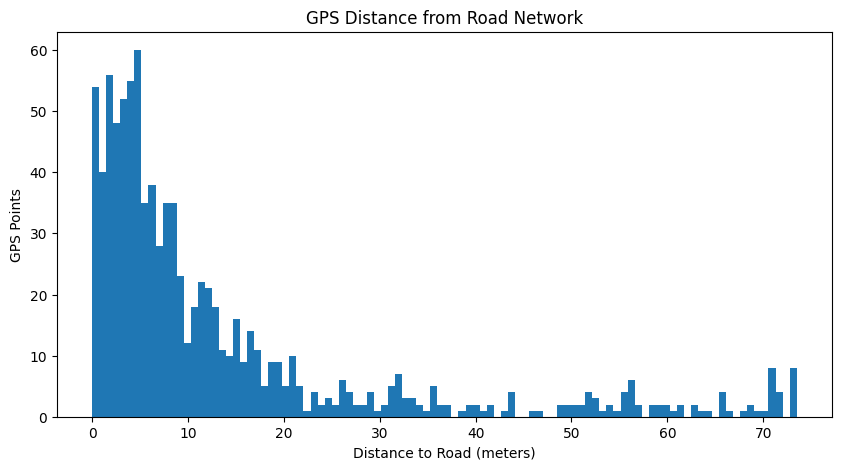

In [174]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.hist(
    matched_gps["distance_to_road_m"].dropna(),
    bins=100
)
plt.xlabel("Distance to Road (meters)")
plt.ylabel("GPS Points")
plt.title("GPS Distance from Road Network")
plt.show()

In [176]:
print(gps_df.columns.tolist())

['entity_id', 'timestamp', 'latitude', 'longitude', 'altitude_ft']


# Prepare GPS Data 
 
sort matched gaps according to time_stamp

In [ ]:
matched_gps = matched_gps.sort_values(
    ["guard_id", "timestamp"]
).reset_index(drop=True)

In [178]:
print(gps_df.head())
print(gps_df.columns.tolist())
print(gps_df["entity_id"].nunique())

  entity_id           timestamp   latitude   longitude  altitude_ft
0       000 2008-10-23 02:53:04  39.984702  116.318417          492
1       000 2008-10-23 02:53:10  39.984683  116.318450          492
2       000 2008-10-23 02:53:15  39.984686  116.318417          492
3       000 2008-10-23 02:53:20  39.984688  116.318385          492
4       000 2008-10-23 02:53:25  39.984655  116.318263          492
['entity_id', 'timestamp', 'latitude', 'longitude', 'altitude_ft']
1


## Create guard_id

In [181]:
# Rename entity_id only if it still exists
if "entity_id" in gps_df.columns:
    gps_df = gps_df.rename(
        columns={"entity_id": "guard_id"}
    )

print("Columns:")
print(gps_df.columns.tolist())

print("\nFirst 5 rows:")
print(gps_df.head())

print("\nUnique guards:")
print(gps_df["guard_id"].nunique())

Columns:
['guard_id', 'timestamp', 'latitude', 'longitude', 'altitude_ft']

First 5 rows:
  guard_id           timestamp   latitude   longitude  altitude_ft
0      000 2008-10-23 02:53:04  39.984702  116.318417          492
1      000 2008-10-23 02:53:10  39.984683  116.318450          492
2      000 2008-10-23 02:53:15  39.984686  116.318417          492
3      000 2008-10-23 02:53:20  39.984688  116.318385          492
4      000 2008-10-23 02:53:25  39.984655  116.318263          492

Unique guards:
1


In [182]:
import geopandas as gpd
gps_gdf = gpd.GeoDataFrame(
    gps_df.copy(),
    geometry=gpd.points_from_xy(
        gps_df["longitude"],
        gps_df["latitude"]
    ),
    crs="EPSG:4326"
)
print(gps_gdf.columns.tolist())
print(gps_gdf.head())

['guard_id', 'timestamp', 'latitude', 'longitude', 'altitude_ft', 'geometry']
  guard_id           timestamp   latitude   longitude  altitude_ft  \
0      000 2008-10-23 02:53:04  39.984702  116.318417          492   
1      000 2008-10-23 02:53:10  39.984683  116.318450          492   
2      000 2008-10-23 02:53:15  39.984686  116.318417          492   
3      000 2008-10-23 02:53:20  39.984688  116.318385          492   
4      000 2008-10-23 02:53:25  39.984655  116.318263          492   

                     geometry  
0   POINT (116.31842 39.9847)  
1  POINT (116.31845 39.98468)  
2  POINT (116.31842 39.98469)  
3  POINT (116.31838 39.98469)  
4  POINT (116.31826 39.98466)  


# Check CRS

In [185]:
print("GPS CRS:", gps_gdf.crs)

GPS CRS: EPSG:4326


## Check Crs of Existing Match_gaps 

In [186]:
print("Matched GPS CRS:", matched_gps.crs)

Matched GPS CRS: EPSG:32650


In [187]:
print(matched_gps.geometry.head())

0    POINT (441807.057 4426281.714)
1    POINT (441809.858 4426279.584)
2    POINT (441807.043 4426279.938)
3    POINT (441804.313 4426280.181)
4    POINT (441793.868 4426276.598)
Name: geometry, dtype: geometry


In [188]:
print(matched_gps.geometry.geom_type.value_counts())

Point    916
Name: count, dtype: int64


In [189]:
print("Matched rows:", len(matched_gps))
print(
    matched_gps[
        [
            "latitude",
            "longitude",
            "distance_to_road_m",
            "road_match_status",
            "highway"
        ]
    ].head(10))

Matched rows: 916
    latitude   longitude  distance_to_road_m road_match_status   highway
0  39.984702  116.318417            5.513269              GOOD  tertiary
1  39.984683  116.318450            3.297444              GOOD  tertiary
2  39.984686  116.318417            3.738673              GOOD  tertiary
3  39.984688  116.318385            4.065703              GOOD  tertiary
4  39.984655  116.318263            0.806703              GOOD  tertiary
5  39.984611  116.318026            3.294199              GOOD  tertiary
6  39.984608  116.317761            2.755575              GOOD  tertiary
7  39.984563  116.317517            6.907046              GOOD  tertiary
8  39.984539  116.317294            8.792879              GOOD  tertiary
9  39.984606  116.317065            0.565673              GOOD  tertiary


In [192]:
print(gps_df.columns.tolist())
print(gps_df["guard_id"].unique())
print("Unique guards:", gps_df["guard_id"].nunique())

['guard_id', 'timestamp', 'latitude', 'longitude', 'altitude_ft']
['000']
Unique guards: 1


# Sort GPs Points

In [193]:
gps_df = gps_df.sort_values(
    ["guard_id", "timestamp"]
).reset_index(drop=True)
print(gps_df.head())

  guard_id           timestamp   latitude   longitude  altitude_ft
0      000 2008-10-23 02:53:04  39.984702  116.318417          492
1      000 2008-10-23 02:53:10  39.984683  116.318450          492
2      000 2008-10-23 02:53:15  39.984686  116.318417          492
3      000 2008-10-23 02:53:20  39.984688  116.318385          492
4      000 2008-10-23 02:53:25  39.984655  116.318263          492


## Previous GPS points

In [194]:
gps_df["prev_latitude"] = (
    gps_df.groupby("guard_id")["latitude"].shift(1))
gps_df["prev_longitude"] = (
    gps_df.groupby("guard_id")["longitude"].shift(1))
gps_df["prev_timestamp"] = (
    gps_df.groupby("guard_id")["timestamp"].shift(1))

In [195]:
print(
    gps_df[
        [
            "guard_id",
            "timestamp",
            "latitude",
            "longitude",
            "prev_latitude",
            "prev_longitude",
            "prev_timestamp"
        ]
    ].head(10))

  guard_id           timestamp   latitude   longitude  prev_latitude  \
0      000 2008-10-23 02:53:04  39.984702  116.318417            NaN   
1      000 2008-10-23 02:53:10  39.984683  116.318450      39.984702   
2      000 2008-10-23 02:53:15  39.984686  116.318417      39.984683   
3      000 2008-10-23 02:53:20  39.984688  116.318385      39.984686   
4      000 2008-10-23 02:53:25  39.984655  116.318263      39.984688   
5      000 2008-10-23 02:53:30  39.984611  116.318026      39.984655   
6      000 2008-10-23 02:53:35  39.984608  116.317761      39.984611   
7      000 2008-10-23 02:53:40  39.984563  116.317517      39.984608   
8      000 2008-10-23 02:53:45  39.984539  116.317294      39.984563   
9      000 2008-10-23 02:53:50  39.984606  116.317065      39.984539   

   prev_longitude      prev_timestamp  
0             NaN                 NaT  
1      116.318417 2008-10-23 02:53:04  
2      116.318450 2008-10-23 02:53:10  
3      116.318417 2008-10-23 02:53:15  
4      

## Calculate Time Gap 

In [197]:
gps_df["time_gap_seconds"] = (
    gps_df["timestamp"] -
    gps_df["prev_timestamp"]
).dt.total_seconds()
print(gps_df["time_gap_seconds"].describe())

count      907.000000
mean        32.952591
std        627.101101
min          1.000000
25%          5.000000
50%          5.000000
75%          5.000000
max      18453.000000
Name: time_gap_seconds, dtype: float64


# Calculate Distance

In [198]:
from geopy.distance import geodesic
def calculate_distance(row):
    if pd.isna(row["prev_latitude"]):
        return 0.0
    return geodesic(
        (row["prev_latitude"], row["prev_longitude"]),
        (row["latitude"], row["longitude"])
    ).meters

In [200]:
gps_df["distance_from_previous_m"] = gps_df.apply(
    calculate_distance,
    axis=1)
print(
    gps_df[
        [
            "guard_id",
            "timestamp",
            "distance_from_previous_m"
        ]
    ].head(10))

  guard_id           timestamp  distance_from_previous_m
0      000 2008-10-23 02:53:04                  0.000000
1      000 2008-10-23 02:53:10                  3.520694
2      000 2008-10-23 02:53:15                  2.838241
3      000 2008-10-23 02:53:20                  2.742220
4      000 2008-10-23 02:53:25                 11.045822
5      000 2008-10-23 02:53:30                 20.824082
6      000 2008-10-23 02:53:35                 22.636903
7      000 2008-10-23 02:53:40                 21.431374
8      000 2008-10-23 02:53:45                 19.232631
9      000 2008-10-23 02:53:50                 20.926559


# Speed Calculate 

In [201]:
gps_df["speed_kmh"] = (
    gps_df["distance_from_previous_m"]
    / gps_df["time_gap_seconds"]
    * 3.6)

In [202]:
gps_df.loc[
    gps_df["time_gap_seconds"] <= 0,
    "speed_kmh"
] = np.nan

In [203]:
gps_df.loc[
    gps_df["prev_timestamp"].isna(),
    "speed_kmh"
] = np.nan

# Speed Distribution

In [204]:
print(
    gps_df["speed_kmh"].describe())

count    907.000000
mean       8.088305
std       10.113526
min        0.000000
25%        3.287738
50%        7.357228
75%       11.431430
max      218.147174
Name: speed_kmh, dtype: float64


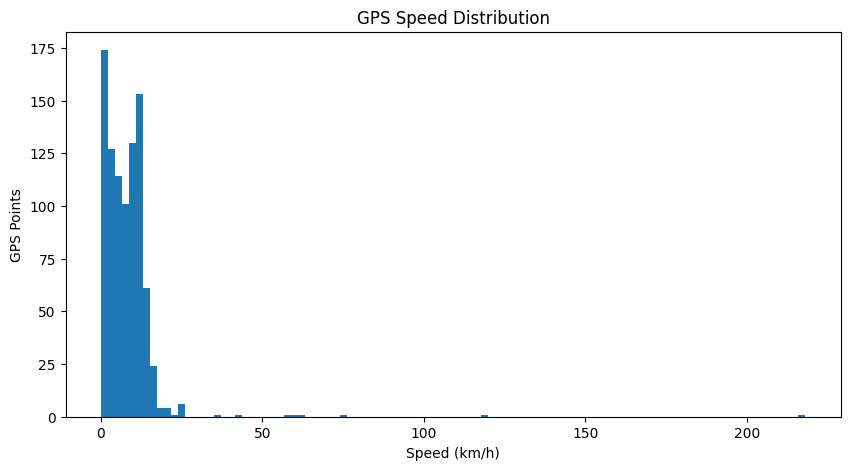

In [205]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.hist(
    gps_df["speed_kmh"].dropna(),
    bins=100
)
plt.xlabel("Speed (km/h)")
plt.ylabel("GPS Points")
plt.title("GPS Speed Distribution")
plt.show()

# Detect GPS Jump

In [207]:
gps_df["gps_jump"] = (
    gps_df["speed_kmh"] > 120
)

In [208]:
print(
    gps_df["gps_jump"].value_counts()
)

gps_jump
False    907
True       1
Name: count, dtype: int64


In [209]:
gps_jumps = gps_df[
    gps_df["gps_jump"]]
print(
    gps_jumps[
        [
            "guard_id",
            "timestamp",
            "latitude",
            "longitude",
            "time_gap_seconds",
            "distance_from_previous_m",
            "speed_kmh"
        ]
    ].head(20))

    guard_id           timestamp   latitude   longitude  time_gap_seconds  \
150      000 2008-10-23 04:08:42  39.984397  116.299292              30.0   

     distance_from_previous_m   speed_kmh  
150               1817.893113  218.147174  


In [210]:
print(matched_gps.columns.tolist())
print(matched_gps.shape)

['latitude', 'longitude', 'altitude', 'timestamp', 'geometry', 'index_right', 'access', 'area', 'bicycle', 'bicycle_road', 'bridge', 'cycleway', 'est_width', 'foot', 'footway', 'highway', 'int_ref', 'junction', 'lanes', 'lit', 'maxspeed', 'motorcar', 'motorroad', 'motor_vehicle', 'name', 'oneway', 'oneway:bicycle', 'overtaking', 'psv', 'ref', 'service', 'segregated', 'sidewalk', 'smoothness', 'surface', 'tracktype', 'tunnel', 'turn', 'width', 'id', 'timestamp_right', 'version', 'tags', 'osm_type', 'length', 'distance_to_road_m', 'road_match_status']
(916, 47)


In [211]:
print(
    matched_gps[
        [
            "latitude",
            "longitude",
            "timestamp",
            "distance_to_road_m",
            "road_match_status"
        ]
    ].head())

    latitude   longitude           timestamp  distance_to_road_m  \
0  39.984702  116.318417 2008-10-23 02:53:04            5.513269   
1  39.984683  116.318450 2008-10-23 02:53:10            3.297444   
2  39.984686  116.318417 2008-10-23 02:53:15            3.738673   
3  39.984688  116.318385 2008-10-23 02:53:20            4.065703   
4  39.984655  116.318263 2008-10-23 02:53:25            0.806703   

  road_match_status  
0              GOOD  
1              GOOD  
2              GOOD  
3              GOOD  
4              GOOD  


# GPS Movement + OSM Features Combine

In [212]:
print(gps_df.shape)
print(gps_df.columns.tolist())
print(gps_df.head())

(908, 12)
['guard_id', 'timestamp', 'latitude', 'longitude', 'altitude_ft', 'prev_latitude', 'prev_longitude', 'prev_timestamp', 'time_gap_seconds', 'distance_from_previous_m', 'speed_kmh', 'gps_jump']
  guard_id           timestamp   latitude   longitude  altitude_ft  \
0      000 2008-10-23 02:53:04  39.984702  116.318417          492   
1      000 2008-10-23 02:53:10  39.984683  116.318450          492   
2      000 2008-10-23 02:53:15  39.984686  116.318417          492   
3      000 2008-10-23 02:53:20  39.984688  116.318385          492   
4      000 2008-10-23 02:53:25  39.984655  116.318263          492   

   prev_latitude  prev_longitude      prev_timestamp  time_gap_seconds  \
0            NaN             NaN                 NaT               NaN   
1      39.984702      116.318417 2008-10-23 02:53:04               6.0   
2      39.984683      116.318450 2008-10-23 02:53:10               5.0   
3      39.984686      116.318417 2008-10-23 02:53:15               5.0   
4      

# OSM Matching Dataset 

In [213]:
osm_features = matched_gps[
    [
        "latitude",
        "longitude",
        "timestamp",
        "distance_to_road_m",
        "road_match_status",
        "highway",
        "maxspeed",
        "length"
    ]
].copy()

print(osm_features.shape)
print(osm_features.head())

(916, 8)
    latitude   longitude           timestamp  distance_to_road_m  \
0  39.984702  116.318417 2008-10-23 02:53:04            5.513269   
1  39.984683  116.318450 2008-10-23 02:53:10            3.297444   
2  39.984686  116.318417 2008-10-23 02:53:15            3.738673   
3  39.984688  116.318385 2008-10-23 02:53:20            4.065703   
4  39.984655  116.318263 2008-10-23 02:53:25            0.806703   

  road_match_status   highway maxspeed  length  
0              GOOD  tertiary     None   401.0  
1              GOOD  tertiary     None   401.0  
2              GOOD  tertiary     None   401.0  
3              GOOD  tertiary     None   401.0  
4              GOOD  tertiary     None   401.0  


# Timestamp in same format 

In [214]:
gps_df["timestamp"] = pd.to_datetime(
    gps_df["timestamp"],
    errors="coerce"
)
osm_features["timestamp"] = pd.to_datetime(
    osm_features["timestamp"],
    errors="coerce")

In [215]:
print(gps_df["timestamp"].dtype)
print(osm_features["timestamp"].dtype)

datetime64[ns]
datetime64[ns]


## Controlled Precision to Coordinates

In [216]:
gps_df["lat_key"] = gps_df["latitude"].round(5)
gps_df["lon_key"] = gps_df["longitude"].round(5)

osm_features["lat_key"] = osm_features["latitude"].round(5)
osm_features["lon_key"] = osm_features["longitude"].round(5)

## GPS + OSM Merge

In [217]:
feature_df = gps_df.merge(
    osm_features,
    on=[
        "lat_key",
        "lon_key",
        "timestamp"
    ],
    how="left",
    suffixes=("", "_osm"))

In [218]:
print(feature_df.shape)
print(
    feature_df[
        [
            "guard_id",
            "timestamp",
            "latitude",
            "longitude",
            "speed_kmh",
            "distance_from_previous_m",
            "distance_to_road_m",
            "road_match_status"
        ]
    ].head(10))

(916, 21)
  guard_id           timestamp   latitude   longitude  speed_kmh  \
0      000 2008-10-23 02:53:04  39.984702  116.318417        NaN   
1      000 2008-10-23 02:53:10  39.984683  116.318450   2.112417   
2      000 2008-10-23 02:53:15  39.984686  116.318417   2.043534   
3      000 2008-10-23 02:53:20  39.984688  116.318385   1.974399   
4      000 2008-10-23 02:53:25  39.984655  116.318263   7.952992   
5      000 2008-10-23 02:53:30  39.984611  116.318026  14.993339   
6      000 2008-10-23 02:53:35  39.984608  116.317761  16.298570   
7      000 2008-10-23 02:53:40  39.984563  116.317517  15.430589   
8      000 2008-10-23 02:53:45  39.984539  116.317294  13.847494   
9      000 2008-10-23 02:53:50  39.984606  116.317065  15.067123   

   distance_from_previous_m  distance_to_road_m road_match_status  
0                  0.000000            5.513269              GOOD  
1                  3.520694            3.297444              GOOD  
2                  2.838241          

## Check Match Coverage

In [219]:
match_percentage = (
    feature_df["distance_to_road_m"]
    .notna()
    .mean()
    * 100)
print(
    f"OSM road match coverage: {match_percentage:.2f}%")

OSM road match coverage: 100.00%


# Road Match Quality Distribution

In [220]:
print(
    feature_df["road_match_status"]
    .value_counts(dropna=False)
)

road_match_status
GOOD          568
ACCEPTABLE    227
VERY_FAR       70
FAR            51
Name: count, dtype: int64


In [221]:
print(
    feature_df["road_match_status"]
    .value_counts(normalize=True, dropna=False)
    .mul(100)
    .round(2))

road_match_status
GOOD          62.01
ACCEPTABLE    24.78
VERY_FAR       7.64
FAR            5.57
Name: proportion, dtype: float64


In [223]:
feature_columns = [
    "guard_id",
    "timestamp",
    "latitude",
    "longitude",
    "altitude_ft",

    "time_gap_seconds",
    "distance_from_previous_m",
    "speed_kmh",
    "gps_jump",

    "distance_to_road_m",
    "road_match_status",

    "highway",
    "maxspeed",
    "length"]

In [224]:
available_features = [
    col for col in feature_columns
    if col in feature_df.columns
]
feature_df = feature_df[available_features].copy()
print(feature_df.shape)
print(feature_df.columns.tolist())

(916, 14)
['guard_id', 'timestamp', 'latitude', 'longitude', 'altitude_ft', 'time_gap_seconds', 'distance_from_previous_m', 'speed_kmh', 'gps_jump', 'distance_to_road_m', 'road_match_status', 'highway', 'maxspeed', 'length']


# Data Quality Report 

In [225]:
quality_report = pd.DataFrame({
    "column": feature_df.columns,
    "missing_count": feature_df.isna().sum().values,
    "missing_percentage": (
        feature_df.isna().mean().values * 100
    ).round(2),
    "unique_values": [
        feature_df[col].nunique()
        for col in feature_df.columns
    ]
})
print(quality_report)

                      column  missing_count  missing_percentage  unique_values
0                   guard_id              0                0.00              1
1                  timestamp              0                0.00            908
2                   latitude              0                0.00            799
3                  longitude              0                0.00            828
4                altitude_ft              0                0.00            314
5           time_gap_seconds              1                0.11             22
6   distance_from_previous_m              0                0.00            882
7                  speed_kmh              1                0.11            882
8                   gps_jump              0                0.00              2
9         distance_to_road_m              0                0.00            882
10         road_match_status              0                0.00              4
11                   highway              0         

# GPS anomaly candidates

In [226]:
gps_jump_candidates = feature_df[
    feature_df["speed_kmh"] > 120
].copy()
print(
    "Potential GPS jumps:",
    len(gps_jump_candidates))

Potential GPS jumps: 1


In [227]:
road_deviation_candidates = feature_df[
    feature_df["distance_to_road_m"] > 50
].copy()
print(
    "Potential road deviations:",
    len(road_deviation_candidates)
)

Potential road deviations: 70


# Save Intermin Dataset

In [228]:
INTERIM_DATA_DIR.mkdir(
    parents=True,
    exist_ok=True)

In [229]:
output_path = (
    INTERIM_DATA_DIR /
    "geolife_gps_osm_features.parquet")
feature_df.to_parquet(
    output_path,
    index=False)
print("Saved:", output_path)

Saved: e:\Internship\Guard_Patrol_Anomaly_Detection\data\interim\geolife_gps_osm_features.parquet
